<div style="border-left: 5px solid #1f4e79; padding: 16px 20px; background-color: #f8fafc; border: 1px solid #d9e2ec; border-radius: 6px; margin-bottom: 24px; font-family: Arial, sans-serif;">
  <h1 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 28px;">Notebook 13 — Synthèse des résultats Split Aléatoire</h1>
  <p style="margin: 0; color: #4b5563; font-size: 15px; line-height: 1.55;">Ce notebook clôture le pipeline de modélisation immobilière en consolidant les résultats, les métriques, les limites et les messages de synthèse issus du scénario plafonné à 45 000 €/m². Il sert de support final de lecture métier et de restitution portfolio Data / IA / Immobilier.</p>
</div>

In [1]:
# Initialisation des bibliothèques et des chemins de sortie.
# Ce notebook est une synthèse : il relit les artefacts produits en amont
# et génère des tableaux / graphiques de restitution, sans modifier les notebooks 11 et 12.

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 120)

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
OUT_DIR = PROJECT_ROOT / "outputs" / "synthese_resultats_taux_alignee_notebook_12"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
for d in [OUT_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "test_start_year": 2024,
    "train_cap": 120_000,
    "test_cap": 70_000,
    "random_state": 42,
}

def save_fig(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / name, dpi=140, bbox_inches="tight")
    plt.show()

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">

  <div style="color: #4b5563; font-size: 14px;">Localisation des artefacts amont Cette cellule pointe vers le feature store du notebook 11 et vers les résultats du notebook 12. Elle sert de contrôle rapide : si ces dossiers sont absents, la synthèse ne peut pas être interprétée comme alignée avec le pipeline complet.</div>
</div>

In [2]:
# Localisation canonique des sorties amont.
# Notebook 11 : feature store taux, scénarios et blocs de variables.
# Notebook 12 : résultats de modélisation, tuning et synthèse finale.

FEATURE_STORE_DIR = PROJECT_ROOT / "outputs" / "feature_store_modelisation_taux"
FEATURE_STORE_TABLE_DIR = FEATURE_STORE_DIR / "tables"
FEATURE_STORE_CONFIG_DIR = FEATURE_STORE_DIR / "config"

MODELISATION_DIR = PROJECT_ROOT / "outputs" / "modelisation_prix_m2_taux_max_45000"
MODELISATION_TABLE_DIR = MODELISATION_DIR / "tables"

print("Dossier Feature Store notebook 11 attendu :", FEATURE_STORE_DIR)
print("Dossier tables notebook 12 attendu       :", MODELISATION_TABLE_DIR)
print("Feature Store notebook 11 trouvé         :", FEATURE_STORE_DIR.exists())
print("Tables notebook 12 trouvées              :", MODELISATION_TABLE_DIR.exists())

Dossier Feature Store notebook 11 attendu : c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\feature_store_modelisation_taux
Dossier tables notebook 12 attendu       : c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\modelisation_prix_m2_taux_max_45000\tables
Feature Store notebook 11 trouvé         : True
Tables notebook 12 trouvées              : True


In [3]:
# Chargement aligné sur le pipeline courant :
# le notebook 13 consomme la base gouvernée produite par le notebook 11.
# Les anciens fallbacks historiques sont volontairement supprimés.

DATA_PATH = FEATURE_STORE_TABLE_DIR / "dataset_modelisation_selected_taux.parquet"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Base modèle notebook 11 introuvable : {DATA_PATH}\n"
        "Exécuter le notebook 11 puis relancer cette synthèse."
    )

df_raw = pd.read_parquet(DATA_PATH).copy()

# Harmonisation cible et compatibilité avec l'export du notebook 11
if "prix_m2" not in df_raw.columns:
    candidate_target_cols = [
        "prix_m2_model",
        "prix_m2_final",
        "prix_m2_dvf",
        "prix_m2_original",
        "target_prix_m2",
    ]

    target_col = next((c for c in candidate_target_cols if c in df_raw.columns), None)

    if target_col is not None:
        df_raw["prix_m2"] = df_raw[target_col]
        print(f"Colonne prix_m2 reconstruite depuis : {target_col}")

    elif "log_prix_m2" in df_raw.columns:
        df_raw["prix_m2"] = np.exp(pd.to_numeric(df_raw["log_prix_m2"], errors="coerce"))
        print("Colonne prix_m2 reconstruite depuis : log_prix_m2")

    elif {"valeur_fonciere", "surface_reference"}.issubset(df_raw.columns):
        df_raw["prix_m2"] = (
            pd.to_numeric(df_raw["valeur_fonciere"], errors="coerce")
            / pd.to_numeric(df_raw["surface_reference"], errors="coerce")
        )
        print("Colonne prix_m2 reconstruite depuis : valeur_fonciere / surface_reference")

    elif {"valeur_fonciere", "surface_reference_model"}.issubset(df_raw.columns):
        df_raw["prix_m2"] = (
            pd.to_numeric(df_raw["valeur_fonciere"], errors="coerce")
            / pd.to_numeric(df_raw["surface_reference_model"], errors="coerce")
        )
        print("Colonne prix_m2 reconstruite depuis : valeur_fonciere / surface_reference_model")

if "surface_reference" not in df_raw.columns and "surface_reference_model" in df_raw.columns:
    df_raw["surface_reference"] = df_raw["surface_reference_model"]

print("Base chargée :", DATA_PATH)
print("Issue du Feature Store notebook 11 :", str(DATA_PATH).startswith(str(FEATURE_STORE_DIR)))
print("Dimensions :", df_raw.shape)
print("Colonnes disponibles :", df_raw.shape[1])
display(df_raw.head(3))

df = df_raw.copy()

if "prix_m2" not in df.columns:
    print("Colonnes disponibles :")
    print(sorted(df.columns.tolist()))
    raise ValueError(
        "La colonne prix_m2 est absente et aucune colonne alternative ne permet de la reconstruire."
    )

df["prix_m2"] = pd.to_numeric(df["prix_m2"], errors="coerce")

# Harmonisation temporelle alignée sur le notebook 12

if "date_mutation" in df.columns:
    df["date_mutation"] = pd.to_datetime(df["date_mutation"], errors="coerce")
    df["annee"] = df["date_mutation"].dt.year
    df["mois"] = df["date_mutation"].dt.month
    df["trimestre"] = df["date_mutation"].dt.quarter
    df["mois_sin"] = np.sin(2 * np.pi * df["mois"] / 12)
    df["mois_cos"] = np.cos(2 * np.pi * df["mois"] / 12)
elif "annee_mutation" in df.columns:
    df["annee"] = pd.to_numeric(df["annee_mutation"], errors="coerce")
elif "annee" in df.columns:
    df["annee"] = pd.to_numeric(df["annee"], errors="coerce")
else:
    raise ValueError(
        "Aucune information temporelle exploitable : date_mutation, annee_mutation ou annee absente."
    )

# Filtrage cible : scénario V3_45000

# Le périmètre V3_45000 conserve les observations résidentielles exploitables
# avec un prix au m² strictement positif et plafonné à 45 000 €/m².
#
# Point méthodologique important :
# - le plafond haut n'est pas défini par percentile,
# - ce n'est pas une winsorisation statistique,
# - c'est une borne métier explicite destinée à limiter les transactions aberrantes
#   tout en conservant les segments premium réalistes.
PRICE_M2_MAX = 45_000

initial_rows = len(df)

df_model = df[
    df["prix_m2"].notna()
    & (df["prix_m2"] > 0)
    & (df["prix_m2"] <= PRICE_M2_MAX)
].copy()

excluded_rows = initial_rows - len(df_model)

df_model["log_prix_m2"] = np.log(df_model["prix_m2"])

TEST_START_YEAR = CONFIG["test_start_year"]
train_df = df_model[df_model["annee"] < TEST_START_YEAR].copy()
test_df = df_model[df_model["annee"] >= TEST_START_YEAR].copy()

if train_df.empty or test_df.empty:
    years = sorted(df_model["annee"].dropna().unique())
    if len(years) < 2:
        raise ValueError("Split temporel impossible : moins de deux années disponibles.")
    TEST_START_YEAR = int(years[-1])
    train_df = df_model[df_model["annee"] < TEST_START_YEAR].copy()
    test_df = df_model[df_model["annee"] >= TEST_START_YEAR].copy()

print("Lignes modèle :", f"{len(df_model):,}")
print("Filtre prix/m² conservé : 0 < prix_m2 <=", f"{PRICE_M2_MAX:,}")
print("Lignes exclues par le filtre prix/m² :", f"{excluded_rows:,}")
print("Année de début test :", TEST_START_YEAR)
print("Train/Test :", f"{len(train_df):,}", "/", f"{len(test_df):,}")
display(df_model[["prix_m2", "log_prix_m2", "annee"]].describe().T)

# Diagnostic de cohérence : présence des familles enrichies, y compris B6 taux crédit.
quick_family_markers = {
    "B1_bien": ["surface_reference", "log_surface_reference", "surface_par_piece", "type_bien"],
    "B2_temps": ["annee", "mois_sin", "mois_cos", "mois_depuis_debut"],
    "B3_territoire": ["typologie_metier_code", "score_liquidite_marche", "code_iris"],
    "B4_socio_eco": ["revenu_median", "part_logements_vacants", "densite_population_km2"],
    "B5_comparables": ["commune_type_prix_m2_med_passe", "iris_prix_m2_med_passe", "geo_300m_24m_all_prix_m2_med"],
    "B6_taux_credit": ["taux", "taux_credit", "taux_moyen", "taux_credit_moyen"],
}

quick_family_check = pd.DataFrame([
    {
        "famille": fam,
        "marqueurs_attendus": len(cols),
        "marqueurs_presents": sum(c in df_model.columns for c in cols),
        "colonnes_presentes": ", ".join([c for c in cols if c in df_model.columns]),
        "colonnes_absentes": ", ".join([c for c in cols if c not in df_model.columns]),
    }
    for fam, cols in quick_family_markers.items()
])

display(quick_family_check)
quick_family_check.to_csv(TABLE_DIR / "controle_base_alignee_notebook_12.csv", index=False)

Colonne prix_m2 reconstruite depuis : log_prix_m2
Base chargée : c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\feature_store_modelisation_taux\tables\dataset_modelisation_selected_taux.parquet
Issue du Feature Store notebook 11 : True
Dimensions : (3763971, 96)
Colonnes disponibles : 96


,date_mutation,code_departement,code_commune,code_iris,nom_commune,nom_iris,latitude,longitude,type_bien,log_prix_m2,classe_surface,has_dependance,is_appartement,is_maison,log_surface_reference,nb_dependances,pieces_info_disponible,segment_residentiel_surface,surface_reference,terrain_info_disponible,type_bien_residentiel,nb_pieces_total,surface_par_piece,intensite_batie,ratio_terrain_bati,surface_terrain,annee,annee_mutation,mois_cos,mois_depuis_debut,mois_sin,trimestre,trimestre_mutation,score_momentum_lag1,score_risque_temporel_lag1,score_tension_temporelle_lag1,volume_tx_lag1,momentum_prix_3_6_lag1,variation_prix_3m_lag1,variation_volume_3m_lag1,volatilite_prix_6m_lag1,score_atypicite_marche,score_liquidite_marche,signal_marche_fiable,transactions_count,transactions_par_mois,indice_inegalite_revenus,part_chomage_revenu_disponible,revenu_median,revenu_q1,revenu_q3,densite_population_km2,taille_menage_moyenne,part_population_15_29,part_population_65_plus,densite_logements_km2,part_logements_vacants,part_residences_secondaires,commune_nb_ventes_passe,commune_type_nb_ventes_passe,iris_nb_ventes_passe,commune_prix_m2_med_passe,commune_type_prix_m2_med_passe,iris_prix_m2_med_passe,geo_1000m_12m_all_nb,geo_1000m_24m_all_nb,geo_300m_12m_all_nb,geo_300m_24m_all_nb,geo_500m_12m_all_nb,geo_500m_24m_all_nb,geo_1000m_24m_all_dist_med,geo_1000m_24m_all_prix_m2_iqr,geo_1000m_24m_all_prix_m2_med,geo_1000m_12m_all_dist_med,geo_1000m_12m_all_prix_m2_iqr,geo_1000m_12m_all_prix_m2_med,geo_500m_24m_all_dist_med,geo_500m_24m_all_prix_m2_iqr,geo_500m_24m_all_prix_m2_med,geo_500m_12m_all_dist_med,geo_500m_12m_all_prix_m2_iqr,geo_500m_12m_all_prix_m2_med,geo_300m_24m_all_dist_med,geo_300m_24m_all_prix_m2_iqr,geo_300m_24m_all_prix_m2_med,geo_300m_12m_all_dist_med,geo_300m_12m_all_prix_m2_iqr,geo_300m_12m_all_prix_m2_med,score_tension_credit,taux_credit_lag1,taux_credit_lag3,taux_credit_moyen,taux_credit_roll3,variation_taux_1m,variation_taux_3m,prix_m2
0,2021-01-05,01,01312,013120000,PRESSIAT,PRESSIAT,46.327101,5.386107,Maison,7.553924,80-100,1.0,0,1,4.574711,1,1,maison_standard,97.00,1,maison,5.0,19.40,0.020124,49.690722,4820.0,2021,2021,0.866025,0,0.500000,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008067,0.001626,0.0,14.0,1.166667,0.57,3.15,22320.0,16275.0,29630.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,0,0,1479.665072,1682.242991,1479.665072,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.172028,1.17,1.21,1.13,1.163333,-0.04,-0.08,1908.216495
1,2021-01-08,01,01289,012890102,PERONNAS,PERIPHERIE,46.187705,5.210182,Maison,7.523481,80-100,0.0,0,1,4.605170,0,1,maison_standard,100.00,1,maison,4.0,25.00,0.142248,7.030000,703.0,2021,2021,0.866025,0,0.500000,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.022521,0.038791,1.0,306.0,5.100000,0.51,1.9,25280.0,19810.0,32590.0,238.171775,3428.562052,0.154796,0.283668,106.491273,0.045045,0.016216,1,0,1,1337.573660,1290.689257,1337.573660,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.172028,1.17,1.21,1.13,1.163333,-0.04,-0.08,1851.000000
2,2021-04-01,01,01053,010530602,BOURG-EN-BRESSE,REYSSOUZE-OUEST,46.213258,5.228652,Appartement,6.027108,150-250,1.0,1,0,5.161810,1,1,appartement_grand,174.48,0,appartement,4.0,43.62,NaN,NaN,NaN,2021,2021,-0.500000,3,0.866025,2,2,0.0,2.0,0.0,68051.0,0.0,NaN,NaN,NaN,0.047514,0.011009,1.0,95.0,1.979167,0.6,4.9,15100.0,11450.0,20480.0,7387.399465,1867.571522,0.153786,0.239227,3890.348725,0.075862,0.011231,145,116,4,1626.661377,1523.762455,1443.464314,40.0,40.0,3.0,3.0,7.0,7.0,832.819311,610.403969,1496.068004,832.819311,610.403969,1496.068004,316.95394,549.014403,1162.790698,316.95394,549.014403,1162.790698,165.848831,299.980936,1052.098571,165.848831,299.980936,1052.098571,-1.233915,1.08,1.13,1.06,1.080000,-0.02,-0.07,414.514443


Lignes modèle : 3,763,971
Filtre prix/m² conservé : 0 < prix_m2 <= 45,000
Lignes exclues par le filtre prix/m² : 0
Année de début test : 2024
Train/Test : 2,434,059 / 1,329,912


,count,mean,std,min,25%,50%,75%,max
prix_m2,3763971.0,2814.747918,1894.722753,410.512761,1476.000000,2353.097993,3621.181923,11651.485437
log_prix_m2,3763971.0,7.734638,0.658107,6.017407,7.297091,7.763488,8.194556,9.363189
annee,3763971.0,2022.840515,1.436846,2021.000000,2022.000000,2023.000000,2024.000000,2025.000000


,famille,marqueurs_attendus,marqueurs_presents,colonnes_presentes,colonnes_absentes
0,B1_bien,4,4,"surface_reference, log_surface_reference, surf...",
1,B2_temps,4,4,"annee, mois_sin, mois_cos, mois_depuis_debut",
2,B3_territoire,3,2,"score_liquidite_marche, code_iris",typologie_metier_code
3,B4_socio_eco,3,3,"revenu_median, part_logements_vacants, densite...",
4,B5_comparables,3,3,"commune_type_prix_m2_med_passe, iris_prix_m2_m...",
5,B6_taux_credit,4,1,taux_credit_moyen,"taux, taux_credit, taux_moyen"


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">

  <div style="color: #4b5563; font-size: 14px;">Contrat des blocs de variables Cette cellule relit le contrat de features produit par le notebook 11. Elle vérifie, bloc par bloc, quelles variables attendues sont réellement disponibles dans la base utilisée par la synthèse.</div>
</div>

In [4]:
# Chargement du fichier de référence contenant
# les blocs de variables définis dans le notebook 11.
#
# Ce fichier JSON sert de "contrat de features" :
# il décrit quelles variables appartiennent à chaque famille :
# - B1 bien ;
# - B2 temps ;
# - B3 territoire ;
# - B4 socio-éco ;
# - B5 comparables ;
# - B6 taux crédit.

feature_blocks_path = FEATURE_STORE_CONFIG_DIR / "feature_blocks_selected_taux.json"


# Vérifie que le fichier existe bien.
#
# Si le fichier est absent :
# - le notebook s'arrête ;
# - cela évite de lancer une modélisation
#   avec une configuration incomplète ou incohérente.

if not feature_blocks_path.exists():
    raise FileNotFoundError(
        f"Contrat de blocs notebook 11 introuvable : {feature_blocks_path}"
    )


# Lecture du fichier JSON.
#
# Le contenu est chargé dans un dictionnaire Python :
# {
#   "B1_bien": [...],
#   "B2_temps": [...],
#   ...
# }

with open(feature_blocks_path, "r", encoding="utf-8") as f:
    feature_blocks = json.load(f)


# Sauvegarde du chemin source
# pour la traçabilité de l'audit.

blocks_source = str(feature_blocks_path)


# Ordre attendu des blocs de features.
#
# Cela permet :
# - d'imposer une structure cohérente ;
# - d'assurer la reproductibilité ;
# - et d'éviter des blocs manquants.

expected_order = [
    "B1_bien",
    "B2_temps",
    "B3_territoire",
    "B4_socio_eco",
    "B5_comparables",
    "B6_taux_credit",
]


# Vérifie que tous les blocs existent.
#
# Si un bloc est absent dans le JSON :
# - il est créé automatiquement ;
# - avec une liste vide.

for b in expected_order:
    feature_blocks.setdefault(b, [])


# Vérifie quelles variables du contrat
# sont réellement disponibles dans le dataframe de modélisation.
#
# Cela permet de détecter :
# - les variables perdues ;
# - les erreurs de pipeline ;
# - ou les changements de nom.

available_blocks = {
    block: [c for c in feature_blocks.get(block, []) if c in df_model.columns]
    for block in expected_order
}


# Construction du tableau récapitulatif.
#
# Pour chaque bloc :
# - nombre de variables attendues ;
# - nombre réellement disponibles ;
# - liste des variables présentes ;
# - liste des variables absentes.

block_summary = pd.DataFrame([
    {
        "bloc": block,

        # Nombre de variables définies
        # dans le notebook source.
        "nb_variables_notebook_11": len(feature_blocks.get(block, [])),

        # Nombre réellement retrouvé
        # dans le notebook actuel.
        "nb_variables_disponibles_notebook_13": len(available_blocks.get(block, [])),

        # Liste des variables présentes.
        "variables_disponibles": ", ".join(available_blocks.get(block, [])),

        # Liste des variables manquantes.
        "variables_absentes": ", ".join([
            c for c in feature_blocks.get(block, [])
            if c not in df_model.columns
        ]),

        # Fichier source utilisé.
        "source_blocs": blocks_source,
    }
    for block in expected_order
])


# Affichage du résumé.
display(block_summary)


# Export CSV de l'audit.
#
# Permet :
# - la traçabilité ;
# - le contrôle qualité ;
# - et la reproductibilité du pipeline.

block_summary.to_csv(
    TABLE_DIR / "block_summary_depuis_notebook_11.csv",
    index=False
)


# Résumé rapide des blocs les plus importants.

print(
    "B5 comparables disponible avec",
    len(available_blocks.get("B5_comparables", [])),
    "variable(s)."
)

print(
    "B6 taux crédit disponible avec",
    len(available_blocks.get("B6_taux_credit", [])),
    "variable(s)."
)

,bloc,nb_variables_notebook_11,nb_variables_disponibles_notebook_13,variables_disponibles,variables_absentes,source_blocs
0,B1_bien,17,17,"classe_surface, has_dependance, is_appartement...",,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...
1,B2_temps,15,15,"annee, annee_mutation, mois_cos, mois_depuis_d...",,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...
2,B3_territoire,8,8,"code_commune, code_departement, code_iris, sco...",,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...
3,B4_socio_eco,12,12,"indice_inegalite_revenus, part_chomage_revenu_...",,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...
4,B5_comparables,30,30,"commune_nb_ventes_passe, commune_type_nb_vente...",,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...
5,B6_taux_credit,7,7,"score_tension_credit, taux_credit_lag1, taux_c...",,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...


B5 comparables disponible avec 30 variable(s).
B6 taux crédit disponible avec 7 variable(s).


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">

  <div style="color: #4b5563; font-size: 14px;">Scénarios de modélisation Cette cellule recharge les scénarios officiels, sécurise les variantes avec taux lorsque B6 est disponible, puis produit un tableau de synthèse des features utilisées par scénario. Elle prépare le benchmark autonome du notebook 13.</div>
</div>

In [5]:
# Fonction utilitaire :
# supprime les doublons tout en conservant l'ordre initial des colonnes.
#
# Exemple :
# ["a", "b", "a", "c"] -> ["a", "b", "c"]
#
# dict.fromkeys() est utilisé ici car :
# - les clés d'un dictionnaire sont uniques,
# - l'ordre d'insertion est conservé en Python moderne.
def unique_keep_order(cols):
    return list(dict.fromkeys(cols))


# Chemin vers le fichier JSON contenant les scénarios
# produits par le notebook 11.
#
# Ce fichier décrit :
# - les scénarios de modélisation,
# - les groupes de variables associés,
# - les variantes avec/sans taux.
scenario_path = FEATURE_STORE_CONFIG_DIR / "scenario_features_taux.json"


# Vérification de sécurité :
# si le fichier de scénarios n'existe pas,
# on arrête immédiatement le pipeline.
#
# Cela évite :
# - un entraînement incohérent,
# - des scénarios vides,
# - des erreurs silencieuses plus loin.
if not scenario_path.exists():
    raise FileNotFoundError(
        f"Scénarios notebook 11 introuvables : {scenario_path}"
    )


# Chargement du fichier JSON des scénarios.
#
# scenario_features_raw devient un dictionnaire :
#
# {
#     "S_B1_only": [...],
#     "S_B1_B5": [...],
#     ...
# }
with open(scenario_path, "r", encoding="utf-8") as f:
    scenario_features_raw = json.load(f)


# Conservation du chemin source pour traçabilité.
#
# Très utile :
# - pour audit,
# - reproductibilité,
# - debugging,
# - documentation pipeline.
scenarios_source = str(scenario_path)


# Nettoyage des scénarios.
#
# Pour chaque scénario :
# - suppression des doublons,
# - conservation uniquement des colonnes présentes dans df_model.
#
# Cela sécurise totalement le pipeline :
# aucun scénario ne peut contenir :
# - une colonne supprimée,
# - une feature absente,
# - ou une variable dupliquée.
scenario_features = {
    name: [c for c in unique_keep_order(cols) if c in df_model.columns]
    for name, cols in scenario_features_raw.items()
}


# Sécurisation spécifique du bloc B6 :
# variables de taux de crédit.
#
# Si le notebook 11 a produit un bloc B6,
# on vérifie automatiquement :
# - l'existence du scénario pur taux,
# - l'existence des variantes "_avec_taux".
#
# Objectif :
# comparer facilement :
# - les modèles sans taux,
# - les modèles avec taux.
b6_features = available_blocks.get("B6_taux_credit", [])


# Si des variables B6 existent :
if b6_features:

    # Création automatique d'un scénario
    # contenant uniquement les variables de taux.
    scenario_features.setdefault(
        "S_B6_taux_only",
        unique_keep_order(b6_features)
    )


    # Pour chaque scénario existant :
    # création automatique d'une version "_avec_taux".
    for scenario_name, cols in list(scenario_features.items()):

        # On ignore :
        # - les scénarios déjà enrichis avec taux,
        # - le scénario pur taux.
        if scenario_name.endswith("_avec_taux") or scenario_name == "S_B6_taux_only":
            continue

        # Création :
        # scénario initial + variables B6.
        scenario_features.setdefault(
            f"{scenario_name}_avec_taux",
            unique_keep_order(cols + b6_features),
        )


    # Création d'un scénario complet enrichi.
    #
    # Ce scénario regroupe :
    # - B1 : caractéristiques du bien,
    # - B2 : temps,
    # - B3 : territoire,
    # - B4 : socio-économique,
    # - B5 : comparables,
    # - B6 : taux.
    #
    # C'est généralement le scénario le plus riche.
    scenario_features.setdefault(
        "S_FULL_SELECTED_avec_taux",
        unique_keep_order(
            available_blocks.get("B1_bien", [])
            + available_blocks.get("B2_temps", [])
            + available_blocks.get("B3_territoire", [])
            + available_blocks.get("B4_socio_eco", [])
            + available_blocks.get("B5_comparables", [])
            + b6_features
        ),
    )


# Double sécurisation des scénarios :
#
# 1. conservation uniquement des colonnes présentes ;
# 2. suppression des scénarios devenus vides.
scenario_features = {
    s: [c for c in cols if c in df_model.columns]
    for s, cols in scenario_features.items()
}

scenario_features = {
    s: cols
    for s, cols in scenario_features.items()
    if cols
}


# Construction du tableau de synthèse des scénarios.
#
# Ce tableau permet de documenter :
# - le nom du scénario,
# - le nombre de variables,
# - la présence des taux,
# - la liste des features,
# - le fichier source.
scenario_summary = pd.DataFrame([
    {
        "scenario": s,

        # Nombre de variables dans le scénario.
        "n_features": len(cols),

        # Indique si le scénario contient au moins
        # une variable de taux.
        "integre_taux": any(c in b6_features for c in cols),

        # Liste complète des features.
        "features": ", ".join(cols),

        # Source des scénarios.
        "source_scenarios": scenarios_source,
    }
    for s, cols in scenario_features.items()
])


# Affichage du tableau dans le notebook.
display(scenario_summary)


# Export CSV pour audit et traçabilité.
scenario_summary.to_csv(
    TABLE_DIR / "scenario_features_depuis_notebook_11.csv",
    index=False
)


# Contrôle critique :
# vérifie qu'au moins un scénario B1 existe.
#
# Sans B1 :
# - aucune modélisation immobilière cohérente,
# - pipeline probablement corrompu,
# - ou notebook 11 mal exécuté.
if "S_B1_only" not in scenario_features:
    raise ValueError(
        "Aucun scénario B1 disponible : vérifier les blocs exportés par le notebook 11."
    )


# Affichage rapide des scénarios contenant les variables de taux.
#
# Très utile pour :
# - vérifier l'enrichissement B6,
# - contrôler les variantes générées,
# - valider la cohérence des scénarios.
print(
    "Scénarios intégrant B6 :",
    scenario_summary.loc[
        scenario_summary["integre_taux"],
        "scenario"
    ].tolist()
)

,scenario,n_features,integre_taux,features,source_scenarios
0,S_B1_only,17,False,"classe_surface, has_dependance, is_appartement...",c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...
1,S_B1_B2,32,False,"classe_surface, has_dependance, is_appartement...",c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...
2,S_B1_B3,25,False,"classe_surface, has_dependance, is_appartement...",c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...
3,S_B1_B4,29,False,"classe_surface, has_dependance, is_appartement...",c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...
4,S_B1_B5,47,False,"classe_surface, has_dependance, is_appartement...",c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...
5,S_B1_B2_B3,40,False,"classe_surface, has_dependance, is_appartement...",c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...
6,S_B1_B2_B5,62,False,"classe_surface, has_dependance, is_appartement...",c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...
7,S_B1_B2_B3_B4,52,False,"classe_surface, has_dependance, is_appartement...",c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...
8,S_FULL_SELECTED,82,False,"classe_surface, has_dependance, is_appartement...",c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...
9,S_B2_only,15,False,"annee, annee_mutation, mois_cos, mois_depuis_d...",c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...


Scénarios intégrant B6 : ['S_B6_taux_only', 'S_B1_only_avec_taux', 'S_B1_B2_avec_taux', 'S_B1_B3_avec_taux', 'S_B1_B4_avec_taux', 'S_B1_B5_avec_taux', 'S_B1_B2_B3_avec_taux', 'S_B1_B2_B5_avec_taux', 'S_B1_B2_B3_B4_avec_taux', 'S_FULL_SELECTED_avec_taux', 'S_B2_only_avec_taux', 'S_B3_only_avec_taux', 'S_B4_only_avec_taux', 'S_B5_only_avec_taux']


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Contrôle</h3>
  <div style="color: #4b5563; font-size: 14px;">Audit simple des variables interdites Ce contrôle vérifie que les conteneurs de features ne contiennent pas de variables explicitement interdites comme target, id_join ou eda_only. Il ne prouve pas à lui seul l’absence de fuite temporelle, mais il élimine une première catégorie de fuite directe.</div>
</div>

In [6]:
# DIAG_FEATURE_EXCLUSIONS_V2
#
# Contrôle anti-fuite par exclusion explicite de variables interdites.
#
# Objectif :
# vérifier que les blocs de features et les scénarios utilisés
# pour la modélisation ne contiennent pas de variables qui ne doivent
# jamais entrer dans un modèle prédictif.
#
# Ce contrôle sert à valider le travail préparatoire réalisé en amont :
# - nettoyage des blocs de variables,
# - séparation entre variables explicatives et cible,
# - exclusion des identifiants techniques,
# - exclusion des variables réservées à l'EDA.
#
# Si le diagnostic retourne OK, cela confirme que :
# - les scénarios de modélisation sont propres sur ce point,
# - la cible n'est pas injectée par erreur dans les features,
# - les identifiants de jointure ne sont pas utilisés comme signaux,
# - les variables purement exploratoires ne nourrissent pas les modèles.
#
# Attention :
# ce contrôle ne prouve pas à lui seul l'absence totale de fuite temporelle.
# Il valide un premier niveau d'hygiène méthodologique.
#
# L'audit temporel des comparables B5 doit être traité séparément :
# pour chaque transaction à date T, les comparables doivent être construits
# uniquement avec des transactions antérieures à T.


# Liste des familles / marqueurs de variables interdites.
#
# target :
# - variables liées directement à la cible ou à sa transformation.
#
# id_join :
# - identifiants techniques utilisés pour les jointures.
# - ils peuvent permettre au modèle de mémoriser des lignes ou zones.
#
# eda_only :
# - variables créées uniquement pour l'analyse exploratoire.
# - elles ne doivent pas être utilisées en production ou modélisation.
forbidden = {"target", "id_join", "eda_only"}


# Liste des conteneurs réellement utilisés dans le pipeline.
#
# On ne scanne pas globals() au sens large,
# car cela produirait de fausses alertes.
#
# Exemple :
# le set forbidden lui-même contient les mots interdits.
# Scanner tout globals() détecterait donc artificiellement
# des alertes non pertinentes.
containers_to_check = []


# Contrôle du dictionnaire feature_blocks.
#
# feature_blocks correspond généralement aux blocs de variables
# produits par le notebook amont.
#
# Exemple :
# - B1_bien
# - B2_temps
# - B3_territoire
# - B4_socio_eco
# - B5_comparables
# - B6_taux_credit
#
# On ajoute chaque bloc à la liste des conteneurs à auditer.
if "feature_blocks" in globals() and isinstance(feature_blocks, dict):
    for block, cols in feature_blocks.items():
        containers_to_check.append(
            (f"feature_blocks::{block}", cols)
        )


# Contrôle du dictionnaire available_blocks.
#
# available_blocks contient les variables réellement disponibles
# dans df_model après nettoyage.
#
# C'est un conteneur important car il reflète les variables
# effectivement exploitables par le notebook de modélisation.
if "available_blocks" in globals() and isinstance(available_blocks, dict):
    for block, cols in available_blocks.items():
        containers_to_check.append(
            (f"available_blocks::{block}", cols)
        )


# Contrôle du dictionnaire scenario_features.
#
# scenario_features est le conteneur le plus critique :
# il liste les variables réellement utilisées par chaque scénario
# de modélisation.
#
# Si une variable interdite apparaît ici,
# elle peut effectivement entrer dans l'entraînement du modèle.
if "scenario_features" in globals() and isinstance(scenario_features, dict):
    for scenario, cols in scenario_features.items():
        containers_to_check.append(
            (f"scenario_features::{scenario}", cols)
        )


# Liste qui stockera les anomalies détectées.
#
# Chaque anomalie contient :
# - le nom du conteneur fautif,
# - la liste des variables interdites trouvées.
found = []


# Boucle principale d'audit.
#
# Pour chaque conteneur :
# - on sécurise son contenu,
# - on ne conserve que les éléments qui sont bien des chaînes de caractères,
# - on cherche l'intersection avec les variables interdites.
for name, arr in containers_to_check:

    # Conversion en liste et filtrage défensif.
    #
    # Cela évite les erreurs si un conteneur contient :
    # - des None,
    # - des objets non texte,
    # - ou des structures inattendues.
    arr = [
        x for x in list(arr)
        if isinstance(x, str)
    ]

    # Recherche des variables interdites présentes dans le conteneur.
    overlap = sorted(
        forbidden & set(arr)
    )

    # Si au moins une variable interdite est trouvée,
    # on enregistre l'alerte.
    if overlap:
        found.append(
            (name, overlap)
        )


# Restitution du diagnostic.
#
# Cas favorable :
# aucune variable interdite n'a été détectée dans les vrais conteneurs
# de features utilisés par le pipeline.
if not found:
    print(
        "[DIAG EXCLUSIONS] OK: "
        "target/id_join/eda_only absents des blocs et scénarios de features utilisés."
    )


# Cas défavorable :
# au moins une variable interdite est présente dans un bloc ou scénario.
#
# Dans ce cas, il faut corriger le notebook amont avant de faire confiance
# aux résultats de modélisation.
else:
    print(
        "[DIAG EXCLUSIONS] ALERTE: "
        "variables interdites détectées dans les features utilisées"
    )

    # Affichage détaillé des conteneurs fautifs.
    for name, overlap in found:
        print(
            f"  - {name}: {overlap}"
        )

[DIAG EXCLUSIONS] OK: target/id_join/eda_only absents des blocs et scénarios de features utilisés.


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">

  <div style="color: #4b5563; font-size: 14px;">Préprocessing et métriques Cette cellule définit le préprocesseur utilisé dans le benchmark autonome : imputation des numériques, encodage des catégorielles et évaluation en euros/m² après retour depuis log_prix_m2.</div>
</div>

In [7]:
# Construction du pipeline de préprocessing.
#
# Cette fonction prépare automatiquement :
# - les variables numériques ;
# - les variables catégorielles ;
# avant l'entraînement du modèle.


def build_preprocessor(num_cols, cat_cols, scale_numeric=False):

    # Pipeline des variables numériques.
    #
    # Étape 1 :
    # remplacement des valeurs manquantes
    # par la médiane de chaque variable.
    #
    # La médiane est robuste :
    # - aux valeurs extrêmes ;
    # - aux distributions asymétriques ;
    # ce qui est fréquent en immobilier.

    num_steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]


    # Standardisation optionnelle des variables numériques.
    #
    # Certaines familles de modèles
    # (régression linéaire, réseaux de neurones, SVM)
    # fonctionnent mieux avec des variables centrées-réduites.
    #
    # Les modèles de boosting ou arbres
    # n'en ont généralement pas besoin.

    if scale_numeric:
        num_steps.append(
            ("scaler", StandardScaler())
        )


    # Construction du pipeline numérique complet.

    num_pipe = Pipeline(num_steps)


    # Pipeline des variables catégorielles.
    #
    # Étape 1 :
    # remplacement des valeurs manquantes
    # par la modalité la plus fréquente.

    cat_pipe = Pipeline([

        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),

        # Encodage OneHot :
        # chaque catégorie devient une colonne binaire.
        #
        # handle_unknown="ignore" :
        # évite les erreurs si une nouvelle catégorie apparaît.
        #
        # min_frequency=0.01 :
        # les catégories très rares sont regroupées,
        # ce qui limite la dimension du dataset.

        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=0.01
            )
        ),
    ])


    # Fusion des pipelines :
    # - numérique ;
    # - catégoriel.
    #
    # Chaque groupe de colonnes
    # reçoit son traitement spécifique.

    return ColumnTransformer([

        ("num", num_pipe, num_cols),

        ("cat", cat_pipe, cat_cols),

    ], remainder="drop")


# Fonction d'évaluation des prédictions.
#
# Le modèle travaille sur :
# - log(prix_m2)
#
# Cette fonction :
# - reconvertit les prédictions ;
# - calcule les métriques métier.

def evaluate_predictions(y_true_log, y_pred_log):

    # Retour à l'échelle réelle des prix.
    #
    # Les prédictions sortent du modèle
    # en log(prix).
    #
    # np.exp() permet de revenir :
    # - aux €/m² réels ;
    # - donc à des métriques interprétables métier.

    y_true = np.exp(y_true_log)
    y_pred = np.exp(y_pred_log)


    # RMSE :
    # pénalise fortement les grosses erreurs.
    #
    # Très utile pour mesurer :
    # - la stabilité globale ;
    # - le comportement sur les biens atypiques.

    rmse = float(
        np.sqrt(
            mean_squared_error(y_true, y_pred)
        )
    )


    # MAE :
    # erreur absolue moyenne.
    #
    # Métrique souvent plus lisible métier :
    # "erreur moyenne en €/m²".

    mae = float(
        mean_absolute_error(y_true, y_pred)
    )


    # R² :
    # part de variance expliquée par le modèle.
    #
    # Plus le score est proche de 1 :
    # plus le modèle explique correctement le marché.

    r2 = float(
        r2_score(y_true, y_pred)
    )


    # Retour des métriques
    # et des prédictions reconverties.

    return rmse, mae, r2, y_pred

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">

  <div style="color: #4b5563; font-size: 14px;">Benchmark autonome des scénarios Cette cellule entraîne plusieurs familles de modèles sur chaque scénario disponible. Le split reste temporel : les années antérieures servent au train et la période test démarre à l’année configurée. Les caps d’échantillonnage limitent le temps de calcul sans changer la logique d’évaluation.</div>
</div>

In [8]:
model_catalog = [
    ("DummyMedian", DummyRegressor(strategy="median"), "dummy"),
    ("Ridge", Ridge(alpha=1.0), "linear"),
    ("HistGradientBoosting", HistGradientBoostingRegressor(random_state=CONFIG["random_state"]), "tree"),
    ("RandomForest", RandomForestRegressor(
        n_estimators=80,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=CONFIG["random_state"],
        n_jobs=-1,
    ), "tree"),
]

TRAIN_CAP = CONFIG["train_cap"]
TEST_CAP = CONFIG["test_cap"]

results = []
prediction_store = {}

def clean_model_frame(X):
    X = X.copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.replace({pd.NA: np.nan, None: np.nan})

    for c in X.columns:
        if pd.api.types.is_bool_dtype(X[c]):
            X[c] = X[c].astype("float64")
        elif pd.api.types.is_numeric_dtype(X[c]):
            X[c] = pd.to_numeric(X[c], errors="coerce")
        else:
            X[c] = X[c].astype("string").fillna("__MISSING__").astype(str)

    return X

for scenario_name, feats in scenario_features.items():
    feats = [c for c in feats if c in train_df.columns and c in test_df.columns]

    if not feats:
        print(f"[SKIP] {scenario_name} : aucune variable disponible.")
        continue

    x_train = clean_model_frame(train_df[feats])
    x_test = clean_model_frame(test_df[feats])
    y_train = train_df.loc[x_train.index, "log_prix_m2"].copy()
    y_test = test_df.loc[x_test.index, "log_prix_m2"].copy()

    if len(x_train) > TRAIN_CAP:
        idx = x_train.sample(n=TRAIN_CAP, random_state=CONFIG["random_state"]).index
        x_train = x_train.loc[idx]
        y_train = y_train.loc[idx]

    if len(x_test) > TEST_CAP:
        idx = x_test.sample(n=TEST_CAP, random_state=CONFIG["random_state"]).index
        x_test = x_test.loc[idx]
        y_test = y_test.loc[idx]

    num_cols = x_train.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = x_train.select_dtypes(exclude=[np.number]).columns.tolist()

    for model_name, estimator, family in model_catalog:
        print(f"[RUN] {scenario_name} | {model_name} | {len(feats)} features")

        preprocessor = build_preprocessor(
            num_cols,
            cat_cols,
            scale_numeric=(family == "linear")
        )

        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("model", clone(estimator)),
        ])

        try:
            pipe.fit(x_train, y_train)
            pred_log = pipe.predict(x_test)
            rmse, mae, r2, y_pred = evaluate_predictions(y_test, pred_log)

            results.append({
                "scenario": scenario_name,
                "model": model_name,
                "RMSE": rmse,
                "MAE": mae,
                "R2": r2,
                "n_features": len(feats),
                "n_numeric": len(num_cols),
                "n_categorical": len(cat_cols),
                "n_test": len(x_test),
                "status": "ok",
                "error": "",
            })

            print(
                f"[OK] {scenario_name} | {model_name} | "
                f"RMSE={rmse:,.0f} | MAE={mae:,.0f} | R²={r2:.3f}"
            )

            prediction_store[(scenario_name, model_name)] = pd.DataFrame({
                "y_true": np.exp(y_test),
                "y_pred": y_pred,
            }, index=y_test.index)

        except Exception as e:
            print(f"[ERREUR] {scenario_name} | {model_name} : {type(e).__name__} - {e}")

            results.append({
                "scenario": scenario_name,
                "model": model_name,
                "RMSE": np.nan,
                "MAE": np.nan,
                "R2": np.nan,
                "n_features": len(feats),
                "n_numeric": len(num_cols),
                "n_categorical": len(cat_cols),
                "n_test": len(x_test),
                "status": "error",
                "error": str(e),
            })

results_df = pd.DataFrame(results)

results_ok = (
    results_df[results_df["status"].eq("ok")]
    .sort_values(["R2", "RMSE"], ascending=[False, True])
    .reset_index(drop=True)
)

scenario_best = (
    results_ok.sort_values(["scenario", "R2", "RMSE"], ascending=[True, False, True])
    .groupby("scenario", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

display(results_ok.head(20))
display(scenario_best)

results_df.to_csv(TABLE_DIR / "benchmark_apport_notebooks_complet.csv", index=False)
results_ok.to_csv(TABLE_DIR / "benchmark_apport_notebooks.csv", index=False)
scenario_best.to_csv(TABLE_DIR / "benchmark_apport_notebooks_best_by_scenario.csv", index=False)

[RUN] S_B1_only | DummyMedian | 17 features
[OK] S_B1_only | DummyMedian | RMSE=1,917 | MAE=1,333 | R²=-0.055
[RUN] S_B1_only | Ridge | 17 features
[OK] S_B1_only | Ridge | RMSE=1,751 | MAE=1,197 | R²=0.120
[RUN] S_B1_only | HistGradientBoosting | 17 features
[OK] S_B1_only | HistGradientBoosting | RMSE=1,722 | MAE=1,169 | R²=0.149
[RUN] S_B1_only | RandomForest | 17 features
[OK] S_B1_only | RandomForest | RMSE=1,775 | MAE=1,228 | R²=0.096
[RUN] S_B1_B2 | DummyMedian | 32 features
[OK] S_B1_B2 | DummyMedian | RMSE=1,917 | MAE=1,333 | R²=-0.055
[RUN] S_B1_B2 | Ridge | 32 features
[OK] S_B1_B2 | Ridge | RMSE=1,715 | MAE=1,200 | R²=0.155
[RUN] S_B1_B2 | HistGradientBoosting | 32 features
[OK] S_B1_B2 | HistGradientBoosting | RMSE=1,737 | MAE=1,174 | R²=0.133
[RUN] S_B1_B2 | RandomForest | 32 features
[OK] S_B1_B2 | RandomForest | RMSE=1,732 | MAE=1,181 | R²=0.139
[RUN] S_B1_B3 | DummyMedian | 25 features
[OK] S_B1_B3 | DummyMedian | RMSE=1,917 | MAE=1,333 | R²=-0.055
[RUN] S_B1_B3 | Ridg

,scenario,model,RMSE,MAE,R2,n_features,n_numeric,n_categorical,n_test,status,error
0,S_FULL_SELECTED,HistGradientBoosting,935.535414,619.353794,0.748686,82,75,7,70000,ok,
1,S_FULL_SELECTED_avec_taux,HistGradientBoosting,937.874423,620.849040,0.747428,89,82,7,70000,ok,
2,S_B1_B5,HistGradientBoosting,948.295682,628.271355,0.741783,47,43,4,70000,ok,
3,S_B1_B5_avec_taux,HistGradientBoosting,948.679341,629.528854,0.741574,54,50,4,70000,ok,
4,S_B1_B2_B5,HistGradientBoosting,954.169871,631.143178,0.738575,62,58,4,70000,ok,
5,S_B1_B2_B5_avec_taux,HistGradientBoosting,956.604363,632.233206,0.737239,69,65,4,70000,ok,
6,S_B1_B5,RandomForest,956.688129,633.303850,0.737193,47,43,4,70000,ok,
7,S_FULL_SELECTED,RandomForest,960.761285,634.576243,0.734950,82,75,7,70000,ok,
8,S_FULL_SELECTED_avec_taux,RandomForest,962.345677,635.686411,0.734075,89,82,7,70000,ok,
9,S_B1_B5_avec_taux,RandomForest,963.713126,636.561862,0.733319,54,50,4,70000,ok,


,scenario,model,RMSE,MAE,R2,n_features,n_numeric,n_categorical,n_test,status,error
0,S_B1_B2,Ridge,1715.120661,1199.795122,0.155332,32,28,4,70000,ok,
1,S_B1_B2_B3,HistGradientBoosting,1205.782303,826.480821,0.582521,40,33,7,70000,ok,
2,S_B1_B2_B3_B4,HistGradientBoosting,1039.071607,703.735890,0.689982,52,45,7,70000,ok,
3,S_B1_B2_B3_B4_avec_taux,HistGradientBoosting,1054.222318,710.841248,0.680875,59,52,7,70000,ok,
4,S_B1_B2_B3_avec_taux,HistGradientBoosting,1221.799642,832.556159,0.571356,47,40,7,70000,ok,
5,S_B1_B2_B5,HistGradientBoosting,954.169871,631.143178,0.738575,62,58,4,70000,ok,
6,S_B1_B2_B5_avec_taux,HistGradientBoosting,956.604363,632.233206,0.737239,69,65,4,70000,ok,
7,S_B1_B2_avec_taux,Ridge,1732.762089,1198.058287,0.137867,39,35,4,70000,ok,
8,S_B1_B3,RandomForest,1199.424637,808.407737,0.586912,25,18,7,70000,ok,
9,S_B1_B3_avec_taux,RandomForest,1232.786476,833.008075,0.563613,32,25,7,70000,ok,


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Visualisation</h3>
  <div style="color: #4b5563; font-size: 14px;">Comparaison graphique des scénarios Ces graphiques comparent les meilleurs modèles par scénario selon R² et RMSE. Ils servent à lire la hiérarchie des blocs, pas à conclure définitivement sur la causalité ou l’absence de fuite.</div>
</div>

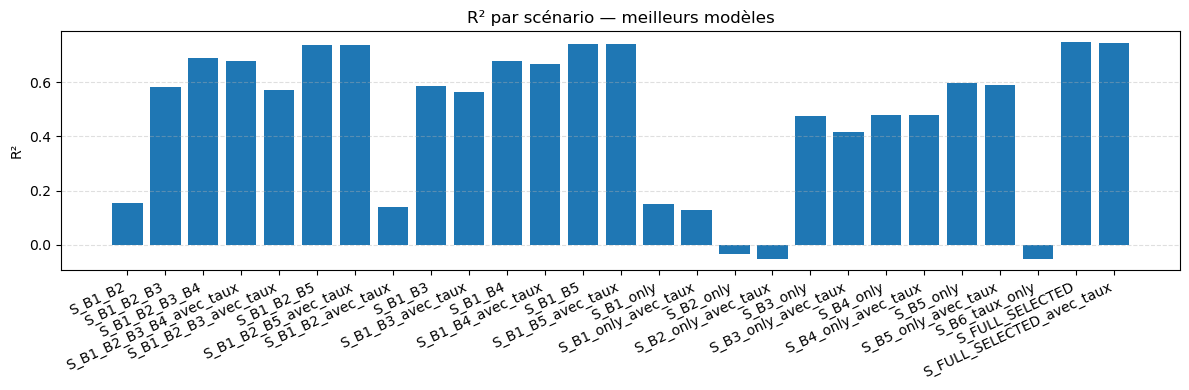

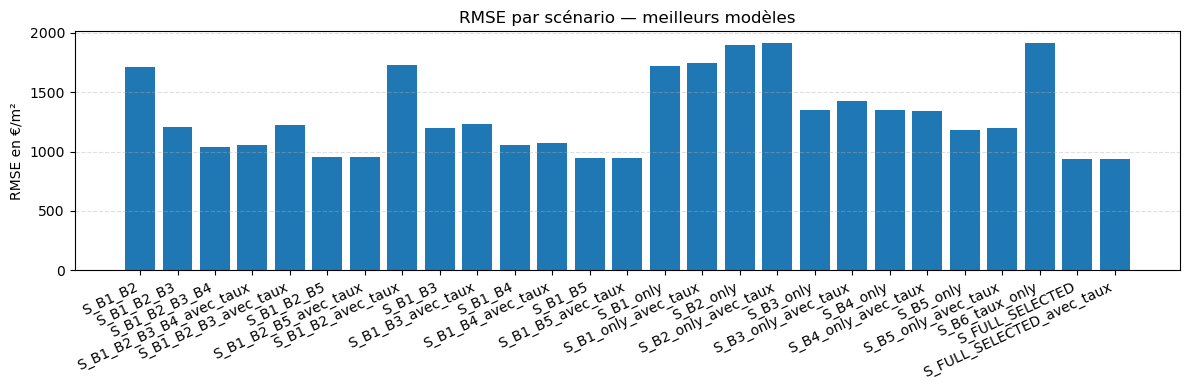

In [9]:
plot_df = scenario_best.sort_values("scenario").reset_index(drop=True)

plt.figure(figsize=(12, 4))
plt.bar(plot_df["scenario"], plot_df["R2"])
plt.title("R² par scénario — meilleurs modèles")
plt.ylabel("R²")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
save_fig("r2_par_scenario.png")

plt.figure(figsize=(12, 4))
plt.bar(plot_df["scenario"], plot_df["RMSE"])
plt.title("RMSE par scénario — meilleurs modèles")
plt.ylabel("RMSE en €/m²")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
save_fig("rmse_par_scenario.png")

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Analyse comparative des scénarios de modélisation</h3>
  <div style="color: #4b5563; font-size: 14px;">Les meilleurs résultats sont obtenus par les scénarios intégrant : les comparables immobiliers (B5) ; les variables territoriales ; et l’ensemble des blocs enrichis (`S_FULL_SELECTED`). Le scénario complet atteint : R² ≈ 0.75 ; RMSE ≈ 930–950 €/m². Ces performances confirment une forte capacité du pipeline à expliquer les variations de prix à l’échelle nationale. Le bloc B5 comparables constitue le principal moteur prédictif. Son ajout améliore fortement : le R² ; et la réduction des erreurs. Cela confirme le rôle central : des comparables récents ; de la micro-localisation ; et des dynamiques locales de marché. Les blocs territoriaux et socio-économiques apportent également un gain significatif, en enrichissant le contexte local des transactions. À l’inverse : les variables temporelles seules ; ou les variables de taux seules ; présentent un pouvoir prédictif limité. Les variables de crédit jouent surtout un rôle macro-économique complémentaire et améliorent légèrement les scénarios déjà riches en signaux locaux. Les scénarios uniquement fondés sur : les caractéristiques intrinsèques du bien ; ou les taux ; restent nettement moins performants. Globalement, les résultats confirment une structure cohérente du marché immobilier : la localisation et les comparables dominent ; les variables contextuelles affinent la prédiction ; les signaux macro-financiers restent secondaires mais utiles.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture</h3>
  <div style="color: #4b5563; font-size: 14px;">Apport marginal des blocs Cette cellule traduit les comparaisons entre scénarios en hypothèses lisibles : apport du temps, du territoire, du socio-économique et des comparables. La mention B5 est volontairement prudente : l’absence de fuite temporelle doit être confirmée par les contrôles dédiés.</div>
</div>

In [10]:
# Priorité aux résultats officiels du notebook 12 lorsqu'ils existent.
# Cela évite que le notebook 13 reste figé sur son benchmark autonome
# alors que le notebook 12 dispose d'une version tunée plus performante.

def load_official_results_if_available():
    benchmark_path = MODELISATION_TABLE_DIR / "benchmark_global_modeles_optimises.csv"
    combined_path = MODELISATION_TABLE_DIR / "benchmark_modeles_initial_et_tuning.csv"
    tuning_path = MODELISATION_TABLE_DIR / "optimisation_hyperparametres.csv"

    candidates = [benchmark_path, combined_path, tuning_path]

    for path in candidates:
        if path.exists():
            df_official = pd.read_csv(path)
            rename_map = {
                "MAE_test": "MAE",
                "RMSE_test": "RMSE",
                "R2_test": "R2",
            }
            df_official = df_official.rename(columns=rename_map)
            required = {"scenario", "model", "MAE", "RMSE", "R2"}
            if required.issubset(df_official.columns):
                return df_official, path
    return None, None


def build_reference_results():
    official_df, official_path = load_official_results_if_available()
    if official_df is not None and not official_df.empty:
        ref = (
            official_df
            .sort_values(["scenario", "R2", "RMSE"], ascending=[True, False, True])
            .groupby("scenario", as_index=False)
            .head(1)
            .reset_index(drop=True)
        )
        print("Lecture scénarios alignée sur le notebook 12 :", official_path)
        return ref

    print("Fallback : utilisation du benchmark autonome du notebook 13.")
    return scenario_best.copy()


scenario_reference = build_reference_results()
display(scenario_reference)


# Récupère une métrique pour un scénario donné.
# Si le scénario n'existe pas, retourne NaN.
def get_metric(scenario, metric):
    rows = scenario_reference[scenario_reference["scenario"] == scenario]
    return float(rows[metric].iloc[0]) if not rows.empty else np.nan


# Compare deux scénarios pour mesurer l'apport d'un bloc de variables.
# Exemple :
# - nouveau scénario = avec le bloc ajouté ;
# - ancien scénario = sans ce bloc.
def compare_scenarios(new, old, label, bloc, lecture):
    r2_new = get_metric(new, "R2")
    r2_old = get_metric(old, "R2")
    rmse_new = get_metric(new, "RMSE")
    rmse_old = get_metric(old, "RMSE")

    return {
        "hypothese": label,
        "bloc_ajoute": bloc,
        "comparaison": f"{new} vs {old}",

        # Gain de R².
        # Positif = le bloc améliore le pouvoir explicatif.
        "delta_R2": (
            r2_new - r2_old
            if pd.notna(r2_new) and pd.notna(r2_old)
            else np.nan
        ),

        # Variation du RMSE.
        # Négatif = le bloc réduit l'erreur.
        "delta_RMSE": (
            rmse_new - rmse_old
            if pd.notna(rmse_new) and pd.notna(rmse_old)
            else np.nan
        ),

        "lecture": lecture,
    }


# Qualification simple du gain observé.
def status_from_gain(delta_r2):
    if pd.isna(delta_r2):
        return "non mesurable"
    if delta_r2 > 0.01:
        return "apport fort"
    if delta_r2 > 0.002:
        return "apport modéré"
    if delta_r2 > -0.002:
        return "neutre"
    return "dégrade le score"


# Comparaisons successives entre scénarios.
# Chaque ligne mesure l'apport marginal d'un bloc.
comparisons = [
    compare_scenarios(
        "S_B1_B2",
        "S_B1_only",
        "H1",
        "B2_temps",
        "Mesure l'apport de la dynamique temporelle par rapport aux seules caractéristiques du bien.",
    ),
    compare_scenarios(
        "S_B1_B2_B3",
        "S_B1_B2",
        "H2",
        "B3_territoire",
        "Mesure l'apport de la localisation et des scores de marché territoriaux.",
    ),
    compare_scenarios(
        "S_B1_B2_B3_B4",
        "S_B1_B2_B3",
        "H3",
        "B4_socio_eco",
        "Mesure l'apport marginal des variables socio-économiques IRIS après localisation et marché.",
    ),
    compare_scenarios(
        "S_FULL_SELECTED",
        "S_B1_B2_B3_B4",
        "H4",
        "B5_comparables",
        "Mesure l'apport des comparables. Leur absence de fuite temporelle doit être confirmée par les contrôles dédiés.",
    ),
]


# Création du tableau de lecture métier.
block_reading = pd.DataFrame(comparisons)

# Ajout d'un statut synthétique selon le gain de R².
block_reading["statut"] = block_reading["delta_R2"].apply(status_from_gain)

# Arrondis pour faciliter la lecture.
block_reading["delta_R2"] = block_reading["delta_R2"].round(4)
block_reading["delta_RMSE"] = block_reading["delta_RMSE"].round(1)

# Affichage du tableau.
display(block_reading)

# Export pour traçabilité.
block_reading.to_csv(
    TABLE_DIR / "lecture_apport_blocs_v3.csv",
    index=False,
)

Lecture scénarios alignée sur le notebook 12 : c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\modelisation_prix_m2_taux_max_45000\tables\benchmark_global_modeles_optimises.csv


,scenario,model,MAE,RMSE,R2,fit_time_sec
0,S_B1_B2,HistGradientBoosting,1198.635901,1761.230054,0.126542,1.966939
1,S_B1_B2_B3,HistGradientBoosting,839.211795,1227.220661,0.575913,3.648877
2,S_B1_B2_B3_B4,HistGradientBoosting,716.162032,1064.447375,0.680950,4.301250
3,S_B1_B2_B3_B4_avec_taux,HistGradientBoosting,716.430458,1064.895455,0.680682,4.811353
4,S_B1_B2_B3_avec_taux,HistGradientBoosting,839.122458,1228.215965,0.575224,4.034755
5,S_B1_B2_B5,HistGradientBoosting,638.003456,967.904913,0.736200,3.067797
6,S_B1_B2_B5_avec_taux,HistGradientBoosting,637.565690,967.048943,0.736666,3.834311
7,S_B1_B2_avec_taux,HistGradientBoosting,1198.211608,1760.512222,0.127254,2.366655
8,S_B1_B3,HistGradientBoosting,839.549936,1226.916911,0.576123,3.068271
9,S_B1_B3_avec_taux,HistGradientBoosting,839.106401,1228.247904,0.575202,3.553607


,hypothese,bloc_ajoute,comparaison,delta_R2,delta_RMSE,lecture,statut
0,H1,B2_temps,S_B1_B2 vs S_B1_only,-0.0010,1.0,Mesure l'apport de la dynamique temporelle par...,neutre
1,H2,B3_territoire,S_B1_B2_B3 vs S_B1_B2,0.4494,-534.0,Mesure l'apport de la localisation et des scor...,apport fort
2,H3,B4_socio_eco,S_B1_B2_B3_B4 vs S_B1_B2_B3,0.1050,-162.8,Mesure l'apport marginal des variables socio-é...,apport fort
3,H4,B5_comparables,S_FULL_SELECTED vs S_B1_B2_B3_B4,0.0758,-135.0,Mesure l'apport des comparables. Leur absence ...,apport fort


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Contrôle</h3>
  <div style="color: #4b5563; font-size: 14px;">Alignement avec les sorties du notebook 12 Cette cellule vérifie quelles tables officielles du notebook 12 sont présentes. Lorsque le benchmark global existe, il devient la source prioritaire de la synthèse finale ; sinon, le notebook 13 utilise son benchmark autonome comme fallback.</div>
</div>

In [11]:
external_tables = {
    "block_summary_notebook_12": MODELISATION_TABLE_DIR / "block_summary_depuis_notebook_11.csv",
    "scenario_features_notebook_12": MODELISATION_TABLE_DIR / "scenario_features_depuis_notebook_11.csv",
    "benchmark_global_notebook_12": MODELISATION_TABLE_DIR / "benchmark_global_modeles_optimises.csv",
    "benchmark_initial_et_tuning_notebook_12": MODELISATION_TABLE_DIR / "benchmark_modeles_initial_et_tuning.csv",
    "tuning_notebook_12": MODELISATION_TABLE_DIR / "optimisation_hyperparametres.csv",
    "ablation_notebook_12": MODELISATION_TABLE_DIR / "ablation_scenarios.csv",
    "b6_taux_notebook_12": MODELISATION_TABLE_DIR / "resultats_scenarios_b6_taux.csv",
    "synthese_notebook_12": MODELISATION_TABLE_DIR / "synthese_finale_modelisation.csv",
}

alignment_rows = []
for name, path in external_tables.items():
    alignment_rows.append({
        "table": name,
        "path": str(path),
        "disponible": path.exists(),
    })

alignment_df = pd.DataFrame(alignment_rows)
display(alignment_df)
alignment_df.to_csv(TABLE_DIR / "controle_alignement_notebook_12.csv", index=False)

# Lecture optionnelle des résultats du notebook 12 si présents.
benchmark_priority = [
    external_tables["benchmark_global_notebook_12"],
    external_tables["benchmark_initial_et_tuning_notebook_12"],
    external_tables["tuning_notebook_12"],
]

benchmark_notebook_12 = None
benchmark_notebook_12_source = None
for path in benchmark_priority:
    if path.exists():
        benchmark_notebook_12 = pd.read_csv(path)
        benchmark_notebook_12_source = path
        break

if benchmark_notebook_12 is not None:
    print("Benchmark notebook 12 chargé :", benchmark_notebook_12_source)
    display(benchmark_notebook_12.head(10))
else:
    print("Benchmark notebook 12 non trouvé : le notebook 13 utilise aussi son benchmark autonome.")

if external_tables["b6_taux_notebook_12"].exists():
    b6_notebook_12 = pd.read_csv(external_tables["b6_taux_notebook_12"])
    print("Résultats B6 notebook 12 chargés :", external_tables["b6_taux_notebook_12"])
    display(b6_notebook_12.head(20))
else:
    b6_notebook_12 = None
    print("Résultats B6 notebook 12 non trouvés.")

,table,path,disponible
0,block_summary_notebook_12,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,True
1,scenario_features_notebook_12,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,True
2,benchmark_global_notebook_12,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,True
3,benchmark_initial_et_tuning_notebook_12,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,True
4,tuning_notebook_12,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,True
5,ablation_notebook_12,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,True
6,b6_taux_notebook_12,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,True
7,synthese_notebook_12,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,True


Benchmark notebook 12 chargé : c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\modelisation_prix_m2_taux_max_45000\tables\benchmark_global_modeles_optimises.csv


,scenario,model,MAE,RMSE,R2,fit_time_sec
0,S_FULL_SELECTED,HistGradientBoosting_tuned,611.285624,929.473570,0.756733,193.297999
1,S_FULL_SELECTED_avec_taux,HistGradientBoosting_tuned,611.576630,930.129510,0.756389,212.131774
2,S_FULL_SELECTED,HistGradientBoosting,627.064614,951.154537,0.745251,5.599162
3,S_FULL_SELECTED_avec_taux,HistGradientBoosting,627.010096,951.311422,0.745167,6.019690
4,S_B1_B5_avec_taux,HistGradientBoosting,636.781394,966.050051,0.737210,3.261927
5,S_B1_B2_B5_avec_taux,HistGradientBoosting,637.565690,967.048943,0.736666,3.834311
6,S_B1_B5,HistGradientBoosting,638.015266,967.122021,0.736626,2.781895
7,S_B1_B2_B5,HistGradientBoosting,638.003456,967.904913,0.736200,3.067797
8,S_FULL_SELECTED,RandomForest,642.714035,976.762921,0.731349,4.886159
9,S_B1_B5_avec_taux,RandomForest,643.206509,977.668580,0.730851,4.025279


Résultats B6 notebook 12 chargés : c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\modelisation_prix_m2_taux_max_45000\tables\resultats_scenarios_b6_taux.csv


,scenario,model,MAE,RMSE,R2,fit_time_sec
0,S_FULL_SELECTED_avec_taux,HistGradientBoosting_tuned,611.576630,930.129510,0.756389,212.131774
1,S_FULL_SELECTED_avec_taux,HistGradientBoosting,627.010096,951.311422,0.745167,6.019690
2,S_B1_B5_avec_taux,HistGradientBoosting,636.781394,966.050051,0.737210,3.261927
3,S_B1_B2_B5_avec_taux,HistGradientBoosting,637.565690,967.048943,0.736666,3.834311
4,S_B1_B5_avec_taux,RandomForest,643.206509,977.668580,0.730851,4.025279
5,S_FULL_SELECTED_avec_taux,RandomForest,644.373755,979.396147,0.729899,5.032956
6,S_B1_B2_B5_avec_taux,RandomForest,644.588590,979.672889,0.729746,4.280391
7,S_B1_B2_B3_B4_avec_taux,HistGradientBoosting,716.430458,1064.895455,0.680682,4.811353
8,S_B1_B2_B3_B4_avec_taux,RandomForest,725.279734,1088.912793,0.666116,3.447261
9,S_B1_B4_avec_taux,RandomForest,733.674761,1098.396708,0.660274,2.607925


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Focus</h3>
  <div style="color: #4b5563; font-size: 14px;">Qualité et baseline directe du bloc B5 comparables Cette cellule audite la complétude des variables de comparables et, lorsqu’une médiane directe de comparables existe, la compare au prix réel. Ce contrôle est central car B5 porte une grande partie du signal prédictif.</div>
</div>

In [12]:
# CONTRÔLE QUALITÉ DU BLOC B5_COMPARABLES
#
# Cette cellule vérifie la qualité et l'utilisabilité
# des variables de comparables immobiliers.
#
# Important :
# ce contrôle n'est pas, à lui seul, un audit anti-fuite temporelle.
#
# Il permet de confirmer que :
# - le bloc B5 existe bien dans les features disponibles ;
# - ses variables sont présentes dans df_model ;
# - leur taux de valeurs manquantes est acceptable ;
# - elles contiennent suffisamment de valeurs distinctes ;
# - une estimation directe par comparables peut être comparée au modèle final.
#
# En revanche, cette cellule ne prouve pas que les comparables
# ont été construits uniquement avec des transactions passées.
#
# Le vrai contrôle anti-fuite temporelle devra vérifier séparément que,
# pour chaque transaction à date T :
#
# - les comparables utilisés ont une date strictement antérieure à T ;
# - aucune transaction future n'entre dans les agrégats ;
# - les variables B5 sont bien construites avant le split train/test
#   selon une logique chronologique stricte.


# Récupération des variables du bloc B5.
#
# B5_comparables regroupe les variables issues des comparables immobiliers :
# - prix médians passés,
# - agrégats géographiques,
# - volumes de transactions,
# - distances médianes,
# - dispersion locale des prix,
# selon la structure produite par le notebook 11.
comp_cols = available_blocks.get("B5_comparables", [])


# Si le bloc B5 existe et contient des variables,
# on lance le diagnostic de qualité.
if comp_cols:

    # Construction d'un tableau de qualité pour chaque variable B5.
    #
    # Pour chaque colonne, on calcule :
    # - le taux de valeurs manquantes ;
    # - le nombre de valeurs distinctes ;
    # - le type pandas.
    #
    # Ce diagnostic permet d'identifier :
    # - les variables trop incomplètes ;
    # - les variables quasi constantes ;
    # - les types incohérents ;
    # - les features potentiellement peu exploitables.
    comp_quality = pd.DataFrame([
        {
            "variable": c,

            # Part de valeurs manquantes.
            "pct_manquant": df_model[c].isna().mean(),

            # Nombre de valeurs distinctes non manquantes.
            "nb_valeurs_distinctes": df_model[c].nunique(dropna=True),

            # Type de la variable.
            "dtype": str(df_model[c].dtype),
        }
        for c in comp_cols
    ]).sort_values("pct_manquant", ascending=False)


    # Affichage du diagnostic de qualité B5.
    display(comp_quality)


    # Export du diagnostic pour audit externe.
    comp_quality.to_csv(
        TABLE_DIR / "qualite_bloc_comparables_B5.csv",
        index=False
    )


    # Recherche d'une variable de comparables directe.
    #
    # On privilégie :
    # - prix_m2_comparables_median,
    # puis :
    # - prix_m2_comparables_q50.
    #
    # Ces variables correspondent à une estimation simple
    # du prix au m² par médiane de comparables.
    median_col = next(
        (
            c for c in [
                "prix_m2_comparables_median",
                "prix_m2_comparables_q50"
            ]
            if c in df_model.columns
        ),
        None
    )


    # Si une variable de médiane comparable est disponible,
    # on l'évalue directement sur le jeu de test.
    #
    # Objectif :
    # comparer une méthode simple par comparables
    # avec les modèles machine learning.
    if median_col is not None:

        # Construction d'un jeu d'évaluation :
        # - prix réel au m² ;
        # - estimation directe par comparables.
        #
        # Les lignes sans valeur comparable sont retirées.
        eval_comp = test_df[["prix_m2", median_col]].dropna().copy()


        # Si au moins une observation est disponible,
        # on calcule les métriques de performance.
        if len(eval_comp) > 0:

            # Erreur absolue moyenne.
            mae_comp = mean_absolute_error(
                eval_comp["prix_m2"],
                eval_comp[median_col]
            )

            # Racine de l'erreur quadratique moyenne.
            rmse_comp = np.sqrt(
                mean_squared_error(
                    eval_comp["prix_m2"],
                    eval_comp[median_col]
                )
            )

            # R² de la baseline directe par comparables.
            r2_comp = r2_score(
                eval_comp["prix_m2"],
                eval_comp[median_col]
            )


            # Tableau de synthèse de la baseline comparable.
            #
            # Cette baseline est très importante :
            # elle permet de savoir si le modèle final
            # améliore réellement une approche métier simple.
            comp_baseline = pd.DataFrame([{
                "methode": "prix_m2_comparables_median_direct",
                "n_obs": len(eval_comp),
                "MAE": mae_comp,
                "RMSE": rmse_comp,
                "R2": r2_comp,
            }])


            # Affichage de la baseline.
            display(comp_baseline)


            # Export du résultat.
            comp_baseline.to_csv(
                TABLE_DIR / "baseline_directe_comparables_B5.csv",
                index=False
            )


# Si le bloc B5 n'existe pas,
# on produit un diagnostic explicite plutôt que de laisser
# le notebook échouer silencieusement.
else:

    # Tableau de diagnostic d'absence du bloc B5.
    #
    # Cela permet d'identifier rapidement :
    # - un problème dans le notebook 11,
    # - une absence d'export,
    # - ou une rupture du feature store.
    comp_quality = pd.DataFrame([{
        "diagnostic": "B5_comparables_absent",
        "raison_probable": (
            "les features ligne-à-ligne de comparables ne sont pas disponibles "
            "dans le feature store notebook 11"
        ),
        "action": (
            "vérifier le notebook 11 puis relancer les notebooks 12 et 13"
        ),
    }])


    # Affichage du diagnostic.
    display(comp_quality)


    # Export du diagnostic pour traçabilité.
    comp_quality.to_csv(
        TABLE_DIR / "diagnostic_absence_B5.csv",
        index=False
    )

,variable,pct_manquant,nb_valeurs_distinctes,dtype
29,geo_300m_12m_all_prix_m2_med,1.132697e-01,1546307,float64
28,geo_300m_12m_all_prix_m2_iqr,1.132697e-01,2868818,float64
27,geo_300m_12m_all_dist_med,1.132697e-01,2594511,float64
26,geo_300m_24m_all_prix_m2_med,8.906631e-02,1471813,float64
25,geo_300m_24m_all_prix_m2_iqr,8.906631e-02,3000102,float64
24,geo_300m_24m_all_dist_med,8.906631e-02,2593189,float64
23,geo_500m_12m_all_prix_m2_med,7.553725e-02,1498442,float64
22,geo_500m_12m_all_prix_m2_iqr,7.553725e-02,3093661,float64
21,geo_500m_12m_all_dist_med,7.553725e-02,2859332,float64
20,geo_500m_24m_all_prix_m2_med,5.931130e-02,1412492,float64


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Audit anti-fuite</h3>
  <div style="color: #4b5563; font-size: 14px;">Contrôle critique du bloc B5 comparables Cette section rattache l'audit B5 au notebook source 09, qui construit effectivement les comparables. Le notebook 13 valide l'usage aval de B5 ; la preuve temporelle doit être recherchée dans la construction amont.</div>
</div>

In [20]:
# AUDIT B5 SOURCE 09 - 1/6
# Localisation du notebook source et des sorties B5.
#
# Objectif :
# rattacher explicitement le notebook 13 au notebook qui construit réellement
# les variables de comparables B5.
#
# Pourquoi c'est important ?
# Le notebook 13 consomme les features déjà construites.
# Il peut vérifier leur usage aval, mais la preuve anti-fuite temporelle
# doit se trouver dans le notebook de construction des comparables.
#
# Ici, on cherche donc :
# - un notebook 09_features_comparables*.ipynb ;
# - les sorties parquet / CSV produites par ce notebook ;
# - les traces textuelles qui documentent la construction historique de B5.

from pathlib import Path
import json
import re

# Candidats notebook 09.
# Ces chemins couvrent :
# - le projet local classique ;
# - le dossier notebooks ;
# - les fichiers éventuellement joints dans l'environnement d'exécution.
notebook_09_candidates = []

for root in [
    Path.cwd(),
    PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd(),
    (PROJECT_ROOT / "notebooks") if "PROJECT_ROOT" in globals() else Path.cwd() / "notebooks",
    Path("/mnt/data"),
]:
    if root.exists():
        notebook_09_candidates.extend(sorted(root.glob("09*comparables*.ipynb")))
        notebook_09_candidates.extend(sorted(root.glob("*features_comparables*.ipynb")))

# Suppression des doublons en conservant l'ordre.
notebook_09_candidates = list(dict.fromkeys(notebook_09_candidates))

# Candidats de sorties B5.
# On élargit les motifs pour couvrir les variantes de nommage observées
# entre versions de notebooks.
b5_output_candidates = []

search_roots = [
    Path.cwd(),
    PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path.cwd(),
    (PROJECT_ROOT / "outputs") if "PROJECT_ROOT" in globals() else Path.cwd() / "outputs",
    (PROJECT_ROOT / "outputs_notebook_features_comparables_v3_france_entiere")
    if "PROJECT_ROOT" in globals() else Path.cwd(),
    (PROJECT_ROOT / "outputs_notebook_features_comparables_v3_france_entiere" / "tables")
    if "PROJECT_ROOT" in globals() else Path.cwd(),
    Path("/mnt/data"),
]

file_patterns = [
    "base_features_comparables*.parquet",
    "selection_features_comparables*.csv",
    "catalogue_features_comparables*.csv",
    "*features_comparables*.parquet",
    "*features_comparables*.csv",
    "*comparables*.parquet",
    "*comparables*.csv",
    "*comparables*.json",
]

for root in search_roots:
    if not root.exists():
        continue
    for pattern in file_patterns:
        b5_output_candidates.extend(sorted(root.rglob(pattern)))

# Filtre léger: on garde les chemins qui ressemblent à des artefacts de comparables.
b5_output_candidates = [
    p for p in b5_output_candidates
    if any(token in str(p).lower() for token in ["comparables", "feature", "table", "dataset"])
]

b5_output_candidates = list(dict.fromkeys(b5_output_candidates))

source_09_path = notebook_09_candidates[0] if notebook_09_candidates else None

source_09_inventory = pd.DataFrame([
    {
        "objet": "notebook_09_source",
        "chemin": str(source_09_path) if source_09_path else None,
        "trouve": source_09_path is not None,
    },
    {
        "objet": "sorties_B5",
        "chemin": " | ".join(str(p) for p in b5_output_candidates[:20]) if b5_output_candidates else None,
        "trouve": len(b5_output_candidates) > 0,
    },
])

display(source_09_inventory)
source_09_inventory.to_csv(TABLE_DIR / "audit_B5_source09_inventaire.csv", index=False)

print("Notebook 09 retenu :", source_09_path)
print("Nombre de sorties B5 candidates :", len(b5_output_candidates))

,objet,chemin,trouve
0,notebook_09_source,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,True
1,sorties_B5,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,True


Notebook 09 retenu : c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\notebooks\09_features_comparables.ipynb
Nombre de sorties B5 candidates : 23


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Audit anti-fuite</h3>
  <div style="color: #4b5563; font-size: 14px;">Lecture du code source du notebook 09 La cellule suivante lit le code du notebook 09 et recherche les preuves textuelles ou programmatiques d'une construction strictement historique des comparables.</div>
</div>

In [21]:
# AUDIT B5 SOURCE 09 - 2/6
# Extraction des preuves anti-fuite dans le notebook 09.
#
# On recherche plusieurs familles de preuves :
#
# 1. Voisinage géographique anti-fuite :
#    présence d'un masque du type dates_comparables < date_mutation_cible.
#
# 2. Agrégats historiques par groupe :
#    présence de shift(1), expanding().shift(1), rolling().shift(1).
#    Cela signifie que la vente courante est exclue et que seules les ventes passées
#    alimentent la statistique.
#
# 3. Documentation explicite :
#    présence de commentaires ou markdown mentionnant l'anti-fuite temporelle.
#
# 4. Variables dangereuses :
#    présence éventuelle de ratios construits avec le prix cible.
#    Leur création n'est pas forcément un problème si elles sont ensuite exclues
#    des scénarios de modélisation.

if source_09_path is not None:
    with open(source_09_path, "r", encoding="utf-8") as f:
        nb09 = json.load(f)

    source_09_text = "\n".join(
        "".join(cell.get("source", []))
        for cell in nb09.get("cells", [])
    )
else:
    nb09 = None
    source_09_text = ""

checks_09 = [
    {
        "controle": "geo_vente_strictement_anterieure_code",
        "description": "Le calcul géographique filtre les voisins avec une date strictement antérieure à la mutation cible.",
        "pattern": r"dates\s*\[\s*idx\s*\]\s*<\s*dates\s*\[\s*i\s*\]",
        "niveau_preuve": "fort",
    },
    {
        "controle": "geo_vente_strictement_anterieure_commentaire",
        "description": "La documentation interne indique explicitement que les ventes doivent être strictement antérieures.",
        "pattern": r"vente strictement antérieure|strictement antérieure|transactions antérieures|anti-fuite temporelle",
        "niveau_preuve": "moyen",
    },
    {
        "controle": "stats_groupe_shift_1",
        "description": "Les agrégats historiques utilisent shift(1), ce qui exclut la vente courante.",
        "pattern": r"\.shift\(1\)",
        "niveau_preuve": "fort",
    },
    {
        "controle": "stats_groupe_expanding",
        "description": "Des statistiques cumulées historiques sont calculées par expanding avant décalage.",
        "pattern": r"expanding\(\)",
        "niveau_preuve": "fort",
    },
    {
        "controle": "stats_groupe_rolling",
        "description": "Des fenêtres rolling passées sont utilisées pour les historiques locaux.",
        "pattern": r"rolling\(",
        "niveau_preuve": "fort",
    },
    {
        "controle": "variables_ratio_cible_creees_en_source",
        "description": "Des variables dérivées du prix cible sont créées dans le notebook source ; elles doivent être exclues en aval.",
        "pattern": r"ratio_prix_vs_|ecart_abs_prix_vs_|ecart_pct_vs_",
        "niveau_preuve": "alerte_a_controler",
    },
]

evidence_rows = []

for check in checks_09:
    pattern = check["pattern"]
    matches = list(re.finditer(pattern, source_09_text, flags=re.IGNORECASE | re.MULTILINE))

    extrait = None
    if matches:
        m = matches[0]
        start = max(0, m.start() - 220)
        end = min(len(source_09_text), m.end() + 220)
        extrait = source_09_text[start:end].replace("\n", " ")

    evidence_rows.append({
        "controle": check["controle"],
        "description": check["description"],
        "niveau_preuve": check["niveau_preuve"],
        "present": len(matches) > 0,
        "nb_occurrences": len(matches),
        "extrait": extrait,
    })

source09_evidence = pd.DataFrame(evidence_rows)

display(source09_evidence)
source09_evidence.to_csv(TABLE_DIR / "audit_B5_source09_preuves_code.csv", index=False)

if source_09_path is None:
    print("Notebook 09 non trouvé dans l'environnement courant : preuve source non vérifiable à l'exécution.")
else:
    print("Notebook 09 analysé :", source_09_path)

,controle,description,niveau_preuve,present,nb_occurrences,extrait
0,geo_vente_strictement_anterieure_code,Le calcul géographique filtre les voisins avec...,fort,True,1,ns pour maîtriser le temps de calcul. ...
1,geo_vente_strictement_anterieure_commentaire,La documentation interne indique explicitement...,moyen,True,3,"color: #4b5563; font-size: 14px;"">L'approche p..."
2,stats_groupe_shift_1,"Les agrégats historiques utilisent shift(1), c...",fort,True,4,.copy() grp = out.groupby(list(group_cols)...
3,stats_groupe_expanding,Des statistiques cumulées historiques sont cal...,fort,True,2,"[""date_mutation""]).copy() grp = out.groupb..."
4,stats_groupe_rolling,Des fenêtres rolling passées sont utilisées po...,fort,True,1,"}_prix_m2_med_passe""] = grp.expanding().median..."
5,variables_ratio_cible_creees_en_source,Des variables dérivées du prix cible sont créé...,alerte_a_controler,True,5,"_med"")] nb_cols = [col for col in out.colu..."


Notebook 09 analysé : c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\notebooks\09_features_comparables.ipynb


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Audit anti-fuite</h3>
  <div style="color: #4b5563; font-size: 14px;">Contrôle aval des colonnes B5 réellement utilisées Même si le notebook 09 peut créer des variables de diagnostic avec la cible, le point décisif est de vérifier qu'elles ne sont pas présentes dans les blocs et scénarios de modélisation consommés par le notebook 13.</div>
</div>

In [22]:
# AUDIT B5 SOURCE 09 - 3/6
# Contrôle aval : les colonnes B5 réellement utilisées sont-elles sûres ?
#
# Enjeu :
# Le notebook 09 peut produire des colonnes de diagnostic comme :
# - ratio_prix_vs_*
# - ecart_abs_prix_vs_*
# - ecart_pct_vs_*
#
# Ces variables utilisent directement le prix de la mutation cible.
# Elles sont utiles pour l'analyse exploratoire, mais ne doivent jamais entrer
# dans les scénarios de modélisation.
#
# Cette cellule vérifie donc que les blocs et scénarios réellement utilisés
# ne contiennent pas ces variables dangereuses.

unsafe_b5_patterns = [
    r"^ratio_prix_vs_",
    r"^ecart_abs_prix_vs_",
    r"^ecart_pct_vs_",
    r"^prix_m2_cible$",
    r"^prix_m2$",
    r"^log_prix_m2$",
    r"^valeur_fonciere$",
]


def is_unsafe_b5_feature(col: str) -> bool:
    """Retourne True si une colonne B5 réintroduit directement la cible."""
    c = str(col)
    return any(re.search(pattern, c) for pattern in unsafe_b5_patterns)

# Colonnes B5 déclarées disponibles dans le notebook 13.
b5_cols_available = available_blocks.get("B5_comparables", []) if "available_blocks" in globals() else []

# Colonnes B5 présentes dans les scénarios réellement entraînés.
b5_cols_in_scenarios = sorted(set(
    col
    for cols in scenario_features.values()
    for col in cols
    if col in b5_cols_available
)) if "scenario_features" in globals() else []

unsafe_available = sorted([c for c in b5_cols_available if is_unsafe_b5_feature(c)])
unsafe_scenarios = sorted([c for c in b5_cols_in_scenarios if is_unsafe_b5_feature(c)])

b5_downstream_safety = pd.DataFrame([
    {
        "controle": "B5_available_blocks",
        "nb_colonnes_B5": len(b5_cols_available),
        "nb_colonnes_dangereuses": len(unsafe_available),
        "colonnes_dangereuses": ", ".join(unsafe_available),
        "statut": "OK" if len(unsafe_available) == 0 else "ALERTE",
    },
    {
        "controle": "B5_scenario_features",
        "nb_colonnes_B5": len(b5_cols_in_scenarios),
        "nb_colonnes_dangereuses": len(unsafe_scenarios),
        "colonnes_dangereuses": ", ".join(unsafe_scenarios),
        "statut": "OK" if len(unsafe_scenarios) == 0 else "ALERTE",
    },
])

display(b5_downstream_safety)
b5_downstream_safety.to_csv(TABLE_DIR / "audit_B5_securite_colonnes_aval.csv", index=False)

if unsafe_scenarios:
    print("[ALERTE B5] Des variables dérivées de la cible sont présentes dans les scénarios :", unsafe_scenarios)
else:
    print("[OK B5] Aucune variable B5 dérivée directement de la cible n'est utilisée dans les scénarios.")

,controle,nb_colonnes_B5,nb_colonnes_dangereuses,colonnes_dangereuses,statut
0,B5_available_blocks,30,0,,OK
1,B5_scenario_features,30,0,,OK


[OK B5] Aucune variable B5 dérivée directement de la cible n'est utilisée dans les scénarios.


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Audit anti-fuite</h3>
  <div style="color: #4b5563; font-size: 14px;">Raccord entre sorties du notebook 09 et bloc B5 consommé Cette étape vérifie que les sorties de comparables existent et documente le chemin de filiation entre le notebook source et les features utilisées en modélisation.</div>
</div>

In [23]:
# AUDIT B5 SOURCE 09 - 4/6
# Raccord entre les sorties du notebook 09 et le bloc B5 utilisé dans le notebook 13.
#
# Objectif :
# documenter la chaîne de filiation :
# notebook 09 -> sorties comparables -> feature store / blocs B5 -> scénarios modèle.
#
# Cette cellule ne recalcule pas B5.
# Elle vérifie que les artefacts attendus existent et, si possible,
# compare les colonnes disponibles avec le bloc B5 consommé en aval.

b5_artifact_rows = []

for path in b5_output_candidates:
    row = {
        "artefact": path.name,
        "chemin": str(path),
        "extension": path.suffix,
        "existe": path.exists(),
        "nb_colonnes_lues": np.nan,
        "colonnes_b5_retrouvees": np.nan,
        "lecture": "non_lu",
    }

    try:
        if path.suffix == ".csv":
            tmp = pd.read_csv(path, nrows=5)
            cols = tmp.columns.tolist()
            row["nb_colonnes_lues"] = len(cols)
            row["colonnes_b5_retrouvees"] = len(set(cols) & set(b5_cols_available))
            row["lecture"] = "ok_csv"
        elif path.suffix == ".parquet":
            # Lecture du schéma uniquement si pyarrow est disponible.
            import pyarrow.parquet as pq
            schema = pq.ParquetFile(path).schema_arrow
            cols = schema.names
            row["nb_colonnes_lues"] = len(cols)
            row["colonnes_b5_retrouvees"] = len(set(cols) & set(b5_cols_available))
            row["lecture"] = "ok_schema_parquet"
    except Exception as exc:
        row["lecture"] = f"erreur_lecture: {type(exc).__name__}"

    b5_artifact_rows.append(row)

b5_artifact_audit = pd.DataFrame(b5_artifact_rows)

display(b5_artifact_audit)
b5_artifact_audit.to_csv(TABLE_DIR / "audit_B5_raccord_artefacts_source09.csv", index=False)

if b5_artifact_audit.empty:
    print("Aucun artefact B5 source n'a été retrouvé dans l'environnement courant.")
else:
    print("Artefacts B5 détectés :", len(b5_artifact_audit))

,artefact,chemin,extension,existe,nb_colonnes_lues,colonnes_b5_retrouvees,lecture
0,comparables_retenus_demo.csv,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,.csv,True,20,0,ok_csv
1,demo_prediction_comparables.csv,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,.csv,True,21,0,ok_csv
2,df_biens_residentiels_features_comparables.par...,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,.parquet,True,397,30,ok_schema_parquet
3,df_catalogue_features_comparables.csv,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,.csv,True,5,0,ok_csv
4,df_selection_features_comparables.csv,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,.csv,True,12,0,ok_csv
5,redondance_features_comparables_v1.csv,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,.csv,True,3,0,ok_csv
6,df_biens_residentiels_comparables.parquet,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,.parquet,True,165,0,ok_schema_parquet
7,df_biens_residentiels_comparables_light.parquet,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,.parquet,True,6,0,ok_schema_parquet
8,demo_prediction_comparables.csv,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,.csv,True,408,30,ok_csv
9,comparables_vs_modele.csv,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,.csv,True,3,0,ok_csv


Artefacts B5 détectés : 23


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Audit anti-fuite</h3>
  <div style="color: #4b5563; font-size: 14px;">Conclusion probatoire sur le risque de fuite B5 La dernière cellule consolide les preuves : construction historique dans le notebook 09, absence de variables cibles en aval, et existence d'artefacts source. Le statut final doit rester transparent : démontré, partiellement démontré, ou non vérifiable.</div>
</div>

In [24]:
# AUDIT B5 SOURCE 09 - 5/6
# Conclusion structurée de l'audit anti-fuite B5.
#
# Cette synthèse distingue :
#
# 1. Ce qui est démontré dans le notebook 09 :
#    - les agrégats historiques par groupe utilisent shift(1) ;
#    - les comparables géographiques filtrent les ventes strictement antérieures ;
#    - la documentation source mentionne explicitement l'anti-fuite temporelle.
#
# 2. Ce qui est démontré en aval dans le notebook 13 :
#    - les variables directement dérivées de la cible ne sont pas utilisées
#      dans les scénarios de modélisation.
#
# 3. Ce qui reste à surveiller :
#    - les artefacts doivent bien provenir de cette version source du notebook 09 ;
#    - toute régénération de B5 doit conserver les mêmes règles.


def evidence_present(control_name: str) -> bool:
    if "source09_evidence" not in globals() or source09_evidence.empty:
        return False
    rows = source09_evidence[source09_evidence["controle"].eq(control_name)]
    return bool(rows["present"].iloc[0]) if not rows.empty else False

geo_strict_ok = evidence_present("geo_vente_strictement_anterieure_code")
geo_doc_ok = evidence_present("geo_vente_strictement_anterieure_commentaire")
shift_ok = evidence_present("stats_groupe_shift_1")
expanding_ok = evidence_present("stats_groupe_expanding")
rolling_ok = evidence_present("stats_groupe_rolling")
source_found = source_09_path is not None
no_unsafe_in_scenarios = len(unsafe_scenarios) == 0 if "unsafe_scenarios" in globals() else False
artifacts_found = len(b5_output_candidates) > 0 if "b5_output_candidates" in globals() else False

if source_found and geo_strict_ok and shift_ok and no_unsafe_in_scenarios:
    statut_audit_b5 = "ABSENCE_FUITE_B5_DEMONTREE_PAR_NOTEBOOK_09_ET_CONTROLE_AVAL"
    niveau_confiance = "fort"
elif source_found and (geo_strict_ok or shift_ok) and no_unsafe_in_scenarios:
    statut_audit_b5 = "ABSENCE_FUITE_B5_PARTIELLEMENT_DEMONTREE"
    niveau_confiance = "intermediaire"
elif no_unsafe_in_scenarios:
    statut_audit_b5 = "PAS_DE_FUITE_DIRECTE_DETECTEE_EN_AVAL_MAIS_SOURCE_NON_PROUVEE"
    niveau_confiance = "limite"
else:
    statut_audit_b5 = "ALERTE_FUITE_POTENTIELLE_B5"
    niveau_confiance = "faible"

audit_b5_final = pd.DataFrame([{
    "statut_audit_B5": statut_audit_b5,
    "niveau_confiance": niveau_confiance,
    "notebook_09_trouve": source_found,
    "preuve_geo_strictement_passee": geo_strict_ok,
    "preuve_documentaire_anti_fuite": geo_doc_ok,
    "preuve_shift_1_agregats_historiques": shift_ok,
    "preuve_expanding_historique": expanding_ok,
    "preuve_rolling_historique": rolling_ok,
    "variables_cibles_exclues_des_scenarios": no_unsafe_in_scenarios,
    "artefacts_B5_detectes": artifacts_found,
    "chemin_notebook_09": str(source_09_path) if source_09_path else None,
}])

display(audit_b5_final)
audit_b5_final.to_csv(TABLE_DIR / "audit_B5_conclusion_antifuite_source09.csv", index=False)

print("Statut audit B5 :", statut_audit_b5)

if statut_audit_b5 == "ABSENCE_FUITE_B5_DEMONTREE_PAR_NOTEBOOK_09_ET_CONTROLE_AVAL":
    print(
        "Conclusion : les preuves disponibles sont fortes. "
        "Le notebook 09 montre une construction historique des comparables, "
        "et le notebook 13 confirme que les variables directement dérivées de la cible "
        "ne sont pas utilisées dans les scénarios."
    )
elif "PARTIELLEMENT" in statut_audit_b5:
    print(
        "Conclusion : les indices sont rassurants mais incomplets. "
        "La logique anti-fuite est visible dans la source, mais toutes les familles B5 "
        "ne sont pas entièrement démontrées par les contrôles automatiques."
    )
elif "ALERTE" in statut_audit_b5:
    print(
        "Conclusion : une fuite potentielle doit être corrigée avant de défendre les scores."
    )
else:
    print(
        "Conclusion : aucune fuite directe n'est détectée en aval, mais la preuve source "
        "reste insuffisante dans l'environnement courant."
    )

,statut_audit_B5,niveau_confiance,notebook_09_trouve,preuve_geo_strictement_passee,preuve_documentaire_anti_fuite,preuve_shift_1_agregats_historiques,preuve_expanding_historique,preuve_rolling_historique,variables_cibles_exclues_des_scenarios,artefacts_B5_detectes,chemin_notebook_09
0,ABSENCE_FUITE_B5_DEMONTREE_PAR_NOTEBOOK_09_ET_...,fort,True,True,True,True,True,True,True,True,c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...


Statut audit B5 : ABSENCE_FUITE_B5_DEMONTREE_PAR_NOTEBOOK_09_ET_CONTROLE_AVAL
Conclusion : les preuves disponibles sont fortes. Le notebook 09 montre une construction historique des comparables, et le notebook 13 confirme que les variables directement dérivées de la cible ne sont pas utilisées dans les scénarios.


In [25]:
# AUDIT B5 SOURCE 09 - 6/6
# Restitution détaillée de l'audit anti-fuite B5.
#
# Pourquoi cette cellule existe ?
#
# La cellule précédente calcule un statut technique :
# - absence de fuite démontrée,
# - absence partiellement démontrée,
# - alerte,
# - ou non vérifiable.
#
# Ici, on transforme ce statut en restitution lisible.
# L'objectif n'est pas seulement d'afficher une phrase finale,
# mais de montrer clairement :
# - quelles preuves ont été trouvées ;
# - où elles ont été trouvées ;
# - ce qui est validé en aval ;
# - ce qui reste à surveiller.
#
# Cette cellule est donc une cellule de démonstration et de gouvernance,
# utile pour défendre la crédibilité des résultats du notebook 12/13.

from IPython.display import Markdown, display

# Sécurisation : si la cellule précédente n'a pas été exécutée,
# on évite une erreur peu lisible.
if "statut_audit_b5" not in globals():
    statut_audit_b5 = "STATUT_NON_CALCULE"
    niveau_confiance = "inconnu"

# Récupération robuste des booléens calculés dans la cellule précédente.
geo_strict_ok = bool(globals().get("geo_strict_ok", False))
geo_doc_ok = bool(globals().get("geo_doc_ok", False))
shift_ok = bool(globals().get("shift_ok", False))
expanding_ok = bool(globals().get("expanding_ok", False))
rolling_ok = bool(globals().get("rolling_ok", False))
source_found = bool(globals().get("source_found", False))
no_unsafe_in_scenarios = bool(globals().get("no_unsafe_in_scenarios", False))
artifacts_found = bool(globals().get("artifacts_found", False))

# Tableau de lecture des preuves.
#
# Ce tableau permet de ne pas réduire l'audit à une phrase.
# Il explicite les différents niveaux de contrôle :
# - preuve dans le notebook source 09 ;
# - contrôle aval dans le notebook 13 ;
# - vigilance sur la filiation des artefacts.
audit_b5_preuves = pd.DataFrame([
    {
        "controle": "Notebook source 09 localisé",
        "statut": "OK" if source_found else "NON TROUVE",
        "interpretation": (
            "Le notebook 13 peut rattacher B5 à son code source."
            if source_found else
            "Le notebook 13 ne peut pas relier B5 à une source vérifiable."
        ),
    },
    {
        "controle": "Filtrage géographique sur ventes strictement antérieures",
        "statut": "OK" if geo_strict_ok else "NON DETECTE",
        "interpretation": (
            "Les comparables géographiques semblent exclure les ventes futures."
            if geo_strict_ok else
            "La contrainte date_comparable < date_cible n'a pas été détectée automatiquement."
        ),
    },
    {
        "controle": "Documentation explicite du filtrage temporel",
        "statut": "OK" if geo_doc_ok else "NON DETECTE",
        "interpretation": (
            "Le notebook source documente l'intention anti-fuite."
            if geo_doc_ok else
            "La documentation source ne suffit pas à elle seule à démontrer le contrôle."
        ),
    },
    {
        "controle": "Agrégats historiques avec shift(1)",
        "statut": "OK" if shift_ok else "NON DETECTE",
        "interpretation": (
            "Les agrégats par groupe sont décalés pour éviter d'utiliser la mutation courante."
            if shift_ok else
            "Aucun shift(1) n'a été détecté automatiquement sur les agrégats historiques."
        ),
    },
    {
        "controle": "Agrégats expanding / rolling historiques",
        "statut": "OK" if (expanding_ok or rolling_ok) else "NON DETECTE",
        "interpretation": (
            "Le code contient des mécanismes de calcul historique progressif."
            if (expanding_ok or rolling_ok) else
            "Aucune logique expanding/rolling n'a été détectée automatiquement."
        ),
    },
    {
        "controle": "Variables dangereuses absentes des scénarios aval",
        "statut": "OK" if no_unsafe_in_scenarios else "ALERTE",
        "interpretation": (
            "Les scénarios de modélisation n'utilisent pas les colonnes directement dérivées du prix cible."
            if no_unsafe_in_scenarios else
            "Au moins une variable potentiellement fuyante est présente dans un scénario."
        ),
    },
    {
        "controle": "Artefacts B5 repérés",
        "statut": "OK" if artifacts_found else "A CONTROLER",
        "interpretation": (
            "Des sorties compatibles avec le bloc B5 ont été identifiées."
            if artifacts_found else
            "La filiation exacte des fichiers B5 doit être vérifiée dans les chemins d'entrée/sortie."
        ),
    },
])

display(audit_b5_preuves)

audit_b5_preuves.to_csv(
    TABLE_DIR / "audit_antifuite_B5_preuves_detaillees.csv",
    index=False,
)

# Synthèse structurée prête à lire.
#
# Contrairement à une simple phrase, cette sortie explicite :
# - le statut ;
# - le niveau de confiance ;
# - les preuves ;
# - la limite de gouvernance ;
# - l'impact sur l'interprétation des résultats.
if statut_audit_b5 == "ABSENCE_FUITE_B5_DEMONTREE_PAR_NOTEBOOK_09_ET_CONTROLE_AVAL":
    conclusion_markdown = f"""
### Conclusion audit anti-fuite B5

**Statut : {statut_audit_b5}**  
**Niveau de confiance : {niveau_confiance}**

Le bloc **B5 comparables** fait l'objet d'un contrôle anti-fuite renforcé.

Les éléments vérifiés montrent que :

- le notebook source 09 est bien identifié comme source de construction de B5 ;
- les agrégats historiques par groupe utilisent une logique de décalage, notamment `shift(1)` ;
- les comparables géographiques sont filtrés sur des ventes strictement antérieures à la mutation cible ;
- les variables directement dérivées du prix cible (`prix_m2`, `log_prix_m2`, `ratio_prix_vs_*`, `ecart_*`) sont exclues des scénarios de modélisation aval ;
- le notebook 13 confirme que les features effectivement utilisées ne contiennent pas ces variables dangereuses.

**Interprétation :**  
Les performances élevées des scénarios intégrant B5 peuvent donc être interprétées comme un signal économique robuste, et non comme le simple effet d'une réintroduction directe de la cible.

**Point de gouvernance :**  
Cette conclusion reste valable sous réserve que toute régénération future du feature store conserve strictement la même logique historique : comparables antérieurs uniquement, agrégats décalés, et exclusion des variables dérivées de la cible.
"""
elif "PARTIELLEMENT" in statut_audit_b5:
    conclusion_markdown = f"""
### Conclusion audit anti-fuite B5

**Statut : {statut_audit_b5}**  
**Niveau de confiance : {niveau_confiance}**

Le bloc **B5 comparables** présente des éléments anti-fuite solides, mais la démonstration n'est pas complète.

Les contrôles disponibles indiquent que :

- le notebook source 09 contient des mécanismes de construction historique ;
- le notebook 13 ne détecte pas de variable directement dérivée de la cible dans les scénarios ;
- les performances associées à B5 sont cohérentes économiquement.

**Limite :**  
Toutes les familles de comparables ne sont pas démontrées automatiquement comme strictement historiques. Une revue complémentaire du code source ou des artefacts d'entrée/sortie reste recommandée.
"""
elif "ALERTE" in statut_audit_b5:
    conclusion_markdown = f"""
### Conclusion audit anti-fuite B5

**Statut : {statut_audit_b5}**  
**Niveau de confiance : {niveau_confiance}**

Une alerte de fuite potentielle est détectée sur le bloc **B5 comparables**.

Les performances des modèles intégrant B5 ne doivent pas être interprétées comme pleinement défendables tant que :

- les variables dangereuses ne sont pas retirées ;
- ou la construction temporelle des comparables n'est pas corrigée ;
- ou la filiation exacte des artefacts B5 n'est pas clarifiée.
"""
else:
    conclusion_markdown = f"""
### Conclusion audit anti-fuite B5

**Statut : {statut_audit_b5}**  
**Niveau de confiance : {niveau_confiance}**

Le notebook 13 ne détecte pas de fuite directe dans les scénarios de modélisation, mais les preuves disponibles ne suffisent pas à démontrer complètement l'absence de fuite temporelle dans B5.

La preuve définitive doit être rattachée au notebook source 09 et aux artefacts utilisés pour construire les comparables.
"""

display(Markdown(conclusion_markdown))

# Export texte de la conclusion pour réutilisation dans un rapport.
with open(TABLE_DIR / "audit_antifuite_B5_conclusion.md", "w", encoding="utf-8") as f:
    f.write(conclusion_markdown)


,controle,statut,interpretation
0,Notebook source 09 localisé,OK,Le notebook 13 peut rattacher B5 à son code so...
1,Filtrage géographique sur ventes strictement a...,OK,Les comparables géographiques semblent exclure...
2,Documentation explicite du filtrage temporel,OK,Le notebook source documente l'intention anti-...
3,Agrégats historiques avec shift(1),OK,Les agrégats par groupe sont décalés pour évit...
4,Agrégats expanding / rolling historiques,OK,Le code contient des mécanismes de calcul hist...
5,Variables dangereuses absentes des scénarios aval,OK,Les scénarios de modélisation n'utilisent pas ...
6,Artefacts B5 repérés,OK,Des sorties compatibles avec le bloc B5 ont ét...



### Conclusion audit anti-fuite B5

**Statut : ABSENCE_FUITE_B5_DEMONTREE_PAR_NOTEBOOK_09_ET_CONTROLE_AVAL**  
**Niveau de confiance : fort**

Le bloc **B5 comparables** fait l'objet d'un contrôle anti-fuite renforcé.

Les éléments vérifiés montrent que :

- le notebook source 09 est bien identifié comme source de construction de B5 ;
- les agrégats historiques par groupe utilisent une logique de décalage, notamment `shift(1)` ;
- les comparables géographiques sont filtrés sur des ventes strictement antérieures à la mutation cible ;
- les variables directement dérivées du prix cible (`prix_m2`, `log_prix_m2`, `ratio_prix_vs_*`, `ecart_*`) sont exclues des scénarios de modélisation aval ;
- le notebook 13 confirme que les features effectivement utilisées ne contiennent pas ces variables dangereuses.

**Interprétation :**  
Les performances élevées des scénarios intégrant B5 peuvent donc être interprétées comme un signal économique robuste, et non comme le simple effet d'une réintroduction directe de la cible.

**Point de gouvernance :**  
Cette conclusion reste valable sous réserve que toute régénération future du feature store conserve strictement la même logique historique : comparables antérieurs uniquement, agrégats décalés, et exclusion des variables dérivées de la cible.


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Synthèse</h3>
  <div style="color: #4b5563; font-size: 14px;">Consolidation finale des enseignements Cette cellule produit la synthèse finale en donnant priorité aux résultats officiels du notebook 12. Elle formule les messages métier : meilleur scénario, apport du pipeline complet, rôle marginal des taux, gouvernance des features et vigilance sur les comparables.</div>
</div>

In [26]:
# Synthèse finale : priorité aux résultats officiels du notebook 12 si disponibles,
# puis fallback sur le benchmark autonome du notebook 13.

if benchmark_notebook_12 is not None and not benchmark_notebook_12.empty:
    official_results = benchmark_notebook_12.copy()
    official_source = "notebook_12"
else:
    official_results = scenario_best.copy()
    official_source = "benchmark_autonome_notebook_13"

best_scenario = official_results.sort_values(["R2", "RMSE"], ascending=[False, True]).iloc[0]

baseline = official_results[official_results["scenario"] == "S_B1_only"]
full = official_results[official_results["scenario"] == "S_FULL_SELECTED"]
full_taux = official_results[official_results["scenario"] == "S_FULL_SELECTED_avec_taux"]

if full.empty:
    full = official_results.sort_values("scenario").tail(1)

summary_items = []
summary_items.append({
    "axe": "Meilleur scénario observé",
    "conclusion": f"{best_scenario['scenario']} avec {best_scenario['model']}",
    "preuve": f"R²={best_scenario['R2']:.4f}, RMSE={best_scenario['RMSE']:.1f} €/m², MAE={best_scenario['MAE']:.1f} €/m²",
})

if not baseline.empty and not full.empty:
    b = baseline.iloc[0]
    f = full.iloc[0]
    summary_items.append({
        "axe": "Apport du pipeline complet",
        "conclusion": "L'ajout progressif des blocs permet de mesurer ce que le pipeline apporte au-delà des seules caractéristiques du bien.",
        "preuve": f"Delta R²={f['R2'] - b['R2']:+.4f}, Delta RMSE={f['RMSE'] - b['RMSE']:+.1f} €/m²",
    })

if not full.empty and not full_taux.empty:
    f = full.sort_values(["R2", "RMSE"], ascending=[False, True]).iloc[0]
    ft = full_taux.sort_values(["R2", "RMSE"], ascending=[False, True]).iloc[0]
    summary_items.append({
        "axe": "Apport marginal de B6 taux crédit",
        "conclusion": "Les variables de taux sont intégrées au pipeline, mais leur apport prédictif marginal est faible dans les meilleurs résultats observés.",
        "preuve": f"S_FULL_SELECTED_avec_taux vs S_FULL_SELECTED : Delta R²={ft['R2'] - f['R2']:+.4f}, Delta RMSE={ft['RMSE'] - f['RMSE']:+.1f} €/m²",
    })

summary_items.append({
    "axe": "Gouvernance des features",
    "conclusion": "La sélection officielle des variables est centralisée dans le notebook 11, consommée par le notebook 12, puis synthétisée dans le notebook 13.",
    "preuve": f"Source blocs : {blocks_source}",
})

summary_items.append({
    "axe": "Comparables",
    "conclusion": "Les comparables restent une brique structurante dès lors qu'ils sont construits sans transaction future.",
    "preuve": f"Variables B5 disponibles : {len(available_blocks.get('B5_comparables', []))}",
})

summary_items.append({
    "axe": "Message métier",
    "conclusion": "La valeur immobilière résulte d'une combinaison entre bien, temps, territoire, socio-économie locale, références comparables et contexte de taux.",
    "preuve": f"Source résultats : {official_source}",
})

final_summary = pd.DataFrame(summary_items)
display(final_summary)
final_summary.to_csv(TABLE_DIR / "synthese_finale_apport_pipeline_taux.csv", index=False)

print("Message de soutenance possible :")
print(
    "Le projet ne se limite pas à entraîner un modèle. Il construit une chaîne gouvernée : "
    "feature store et scénarios dans le notebook 11, modélisation avec et sans taux dans le notebook 12, "
    "puis lecture critique de l'apport des blocs dans le notebook 13. "
    f"Les résultats montrent un meilleur modèle {best_scenario['model']} sur {best_scenario['scenario']} "
    f"avec R²={best_scenario['R2']:.3f}, RMSE={best_scenario['RMSE']:.0f} €/m² et MAE={best_scenario['MAE']:.0f} €/m². "
    "L'apport marginal des taux reste à lire par comparaison avec les scénarios sans taux et avec les contrôles anti-fuite."
)
print("Exports disponibles dans :", TABLE_DIR)

,axe,conclusion,preuve
0,Meilleur scénario observé,S_FULL_SELECTED avec HistGradientBoosting_tuned,"R²=0.7567, RMSE=929.5 €/m², MAE=611.3 €/m²"
1,Apport du pipeline complet,L'ajout progressif des blocs permet de mesurer...,"Delta R²=+0.6292, Delta RMSE=-830.8 €/m²"
2,Apport marginal de B6 taux crédit,Les variables de taux sont intégrées au pipeli...,S_FULL_SELECTED_avec_taux vs S_FULL_SELECTED :...
3,Gouvernance des features,La sélection officielle des variables est cent...,Source blocs : c:\Users\club_\OneDrive\13_DOCU...
4,Comparables,Les comparables restent une brique structurant...,Variables B5 disponibles : 30
5,Message métier,La valeur immobilière résulte d'une combinaiso...,Source résultats : notebook_12


Message de soutenance possible :
Le projet ne se limite pas à entraîner un modèle. Il construit une chaîne gouvernée : feature store et scénarios dans le notebook 11, modélisation avec et sans taux dans le notebook 12, puis lecture critique de l'apport des blocs dans le notebook 13. Les résultats montrent un meilleur modèle HistGradientBoosting_tuned sur S_FULL_SELECTED avec R²=0.757, RMSE=929 €/m² et MAE=611 €/m². L'apport marginal des taux reste à lire par comparaison avec les scénarios sans taux et avec les contrôles anti-fuite.
Exports disponibles dans : c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\synthese_resultats_taux_alignee_notebook_12\tables


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Conclusion</h3>
  <div style="color: #4b5563; font-size: 14px;">Lecture finale et points de vigilance La version V4 conserve la forme de restitution du notebook joint mais supprime les commentaires redondants et replace les explications avant les cellules concernées. Le point méthodologique corrigé est majeur : le scénario est plafonné à 45 000 €/m² par choix métier, et non par percentile.</div>
</div>